In [253]:
import os
import math
import dill
from itertools import permutations

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import pandas as pd
from pingouin import mixed_anova, anova, pairwise_tukey, pairwise_ttests
from statsmodels.regression.mixed_linear_model import MixedLM
from scipy.ndimage import gaussian_filter1d
import matplotlib

import suite2p as s2p

import TwoPUtils as tpu
import STX3KO_analyses as stx
from STX3KO_analyses import utilities_ES as u

ko_mice = stx.ymaze_sess_deets.ko_vr_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_vr_mice
ctrl_sessions = stx.ymaze_sess_deets.CTRL_sessions
ko_sessions = stx.ymaze_sess_deets.KO_sessions

plt.rcParams['pdf.fonttype']=42

fig_dir = "C:/Users/esay/data/Stx3/YMazeResults/behavior"

%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [66]:
dt = 15.46

### Original Analysis (to reference)

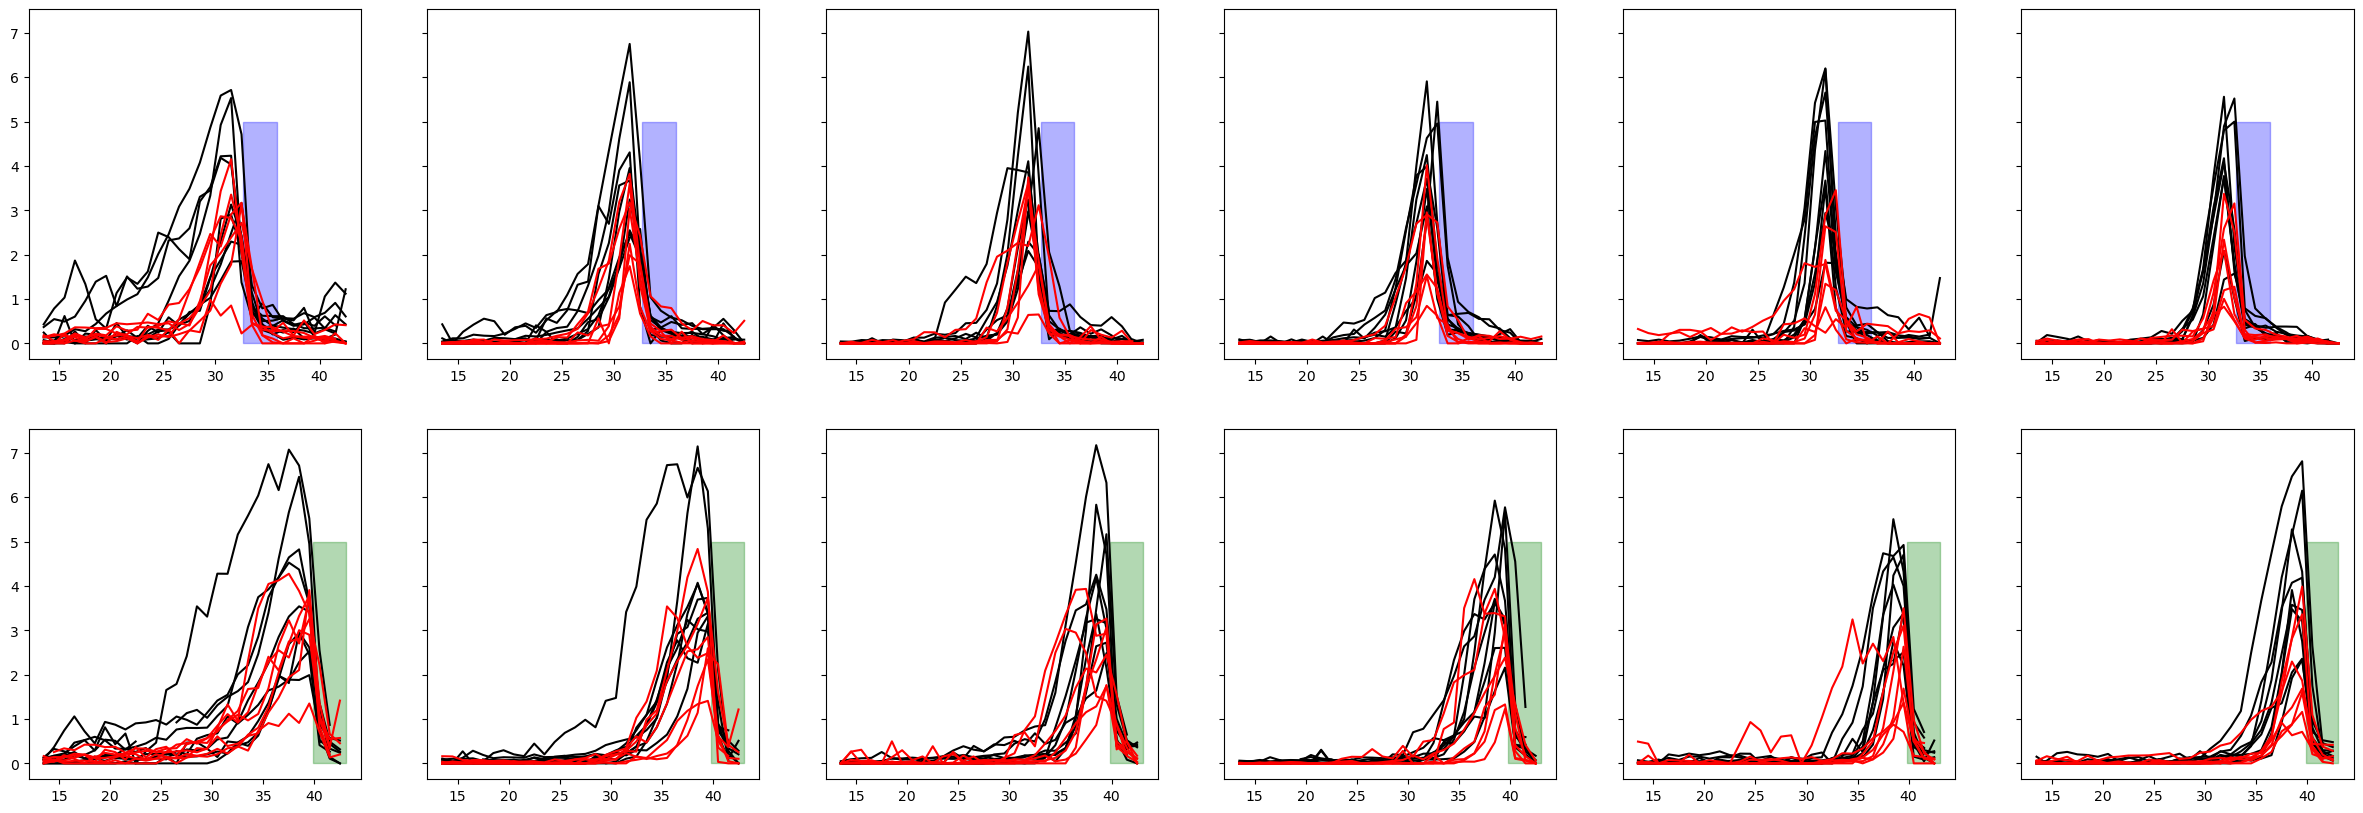

In [231]:
fig, ax = plt.subplots(2,6,figsize=[30,10], sharey=True)

ko_lr = {}
ctrl_lr = {}
for day in range(6):
    
    ctrl_lr[day]={'left':[],'right':[]}
    for i, mouse in enumerate(ctrl_mice):
        sess = u.load_vr_day(mouse,day, trial_mat_keys = ('licks','nonconsum_licks','speed'),verbose = False)
        
        ax[0,day].plot(sess.trial_matrices['bin_centers'], dt*sess.trial_matrices['licks'][sess.trial_info['LR']==-1,:].mean(axis=0),color='black')
        ax[1,day].plot(sess.trial_matrices['bin_centers'], dt*sess.trial_matrices['licks'][sess.trial_info['LR']==1,:].mean(axis=0),color='black')
        
        if i == 0:
            ax[1,day].fill_betweenx([0,5], sess.rzone_late['tfront'], sess.rzone_late['tback'],zorder=0, color='green',alpha=.3)
            ax[0,day].fill_betweenx([0,5],sess.rzone_early['tfront'], sess.rzone_early['tback'],zorder=0, color='blue',alpha=.3)
            
            t_bins = sess.trial_matrices['bin_edges'][1:]
            rzone_early = (t_bins>=sess.rzone_early['tfront']-3)*(t_bins<=sess.rzone_early['tfront'])
            rzone_late = (t_bins>=sess.rzone_late['tfront']-3)*(t_bins<=sess.rzone_late['tfront'])
            
        ctrl_lr[day]['left'].append(dt*np.nanmean(sess.trial_matrices['licks'][sess.trial_info['LR']==-1,:][:,rzone_early]))
        ctrl_lr[day]['right'].append(dt*np.nanmean(sess.trial_matrices['licks'][sess.trial_info['LR']==1,:][:,rzone_late]))
        
    ko_lr[day]={'left':[],'right':[]}
    for i, mouse in enumerate(ko_mice):
        try:
            sess = u.load_vr_day(mouse,day, verbose=False)
            trial_mask = sess.trial_info['LR']==-1
            if day==0 and i == 3:
                trial_mask[35:66]=False

            ax[0,day].plot(sess.trial_matrices['bin_centers'], dt*sess.trial_matrices['licks'][trial_mask,:].mean(axis=0),color='red')
            ax[1,day].plot(sess.trial_matrices['bin_centers'], dt*sess.trial_matrices['licks'][sess.trial_info['LR']==1,:].mean(axis=0),color='red')

            ko_lr[day]['left'].append(dt*np.nanmean(sess.trial_matrices['licks'][trial_mask,:][:,rzone_early]))
            ko_lr[day]['right'].append(dt*np.nanmean(sess.trial_matrices['licks'][sess.trial_info['LR']==1,:][:,rzone_late]))
        except:
            pass

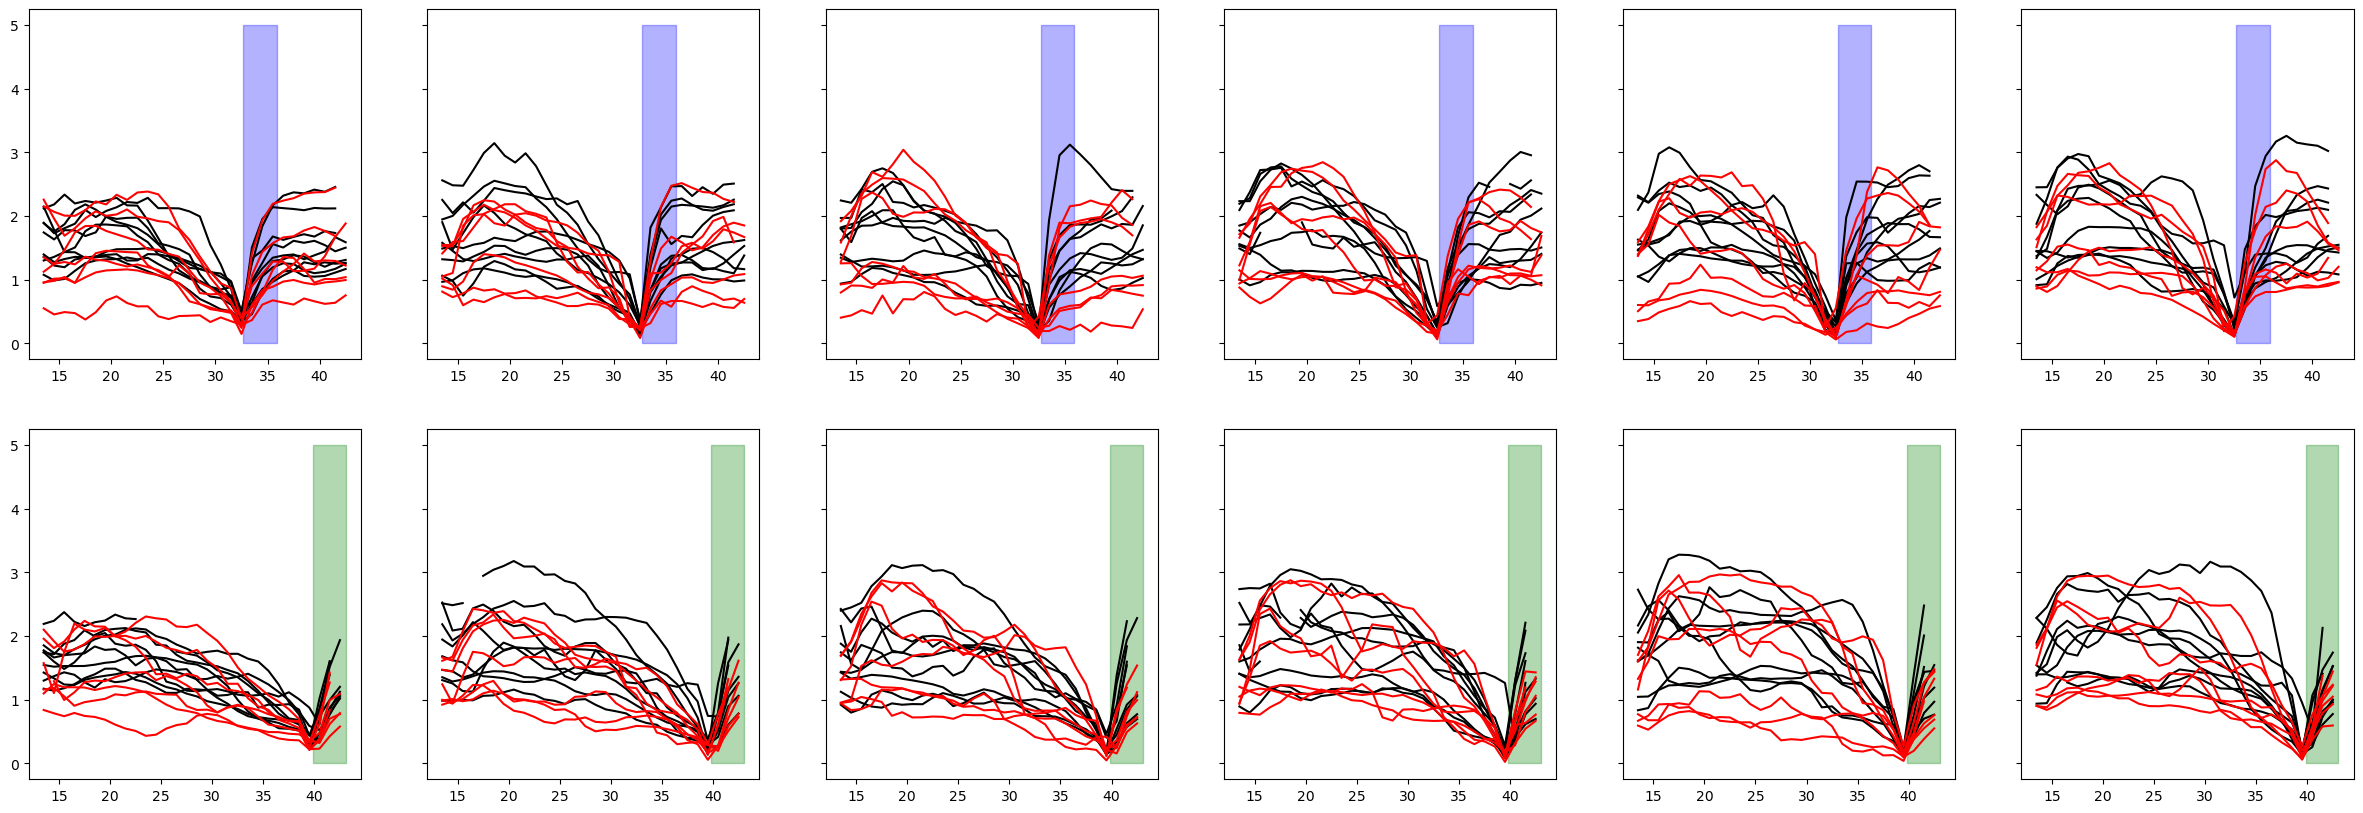

In [232]:
fig, ax = plt.subplots(2,6,figsize=[30,10], sharey=True)

ko_lr = {}
ctrl_lr = {}
for day in range(6):
    
    ctrl_lr[day]={'left':[],'right':[]}
    for i, mouse in enumerate(ctrl_mice):
        sess = u.load_vr_day(mouse,day, trial_mat_keys = ('licks','nonconsum_licks','speed'),verbose = False)
        
        ax[0,day].plot(sess.trial_matrices['bin_centers'], dt*sess.trial_matrices['speed'][sess.trial_info['LR']==-1,:].mean(axis=0),color='black')
        ax[1,day].plot(sess.trial_matrices['bin_centers'], dt*sess.trial_matrices['speed'][sess.trial_info['LR']==1,:].mean(axis=0),color='black')
        
        if i == 0:
            ax[1,day].fill_betweenx([0,5], sess.rzone_late['tfront'], sess.rzone_late['tback'],zorder=0, color='green',alpha=.3)
            ax[0,day].fill_betweenx([0,5],sess.rzone_early['tfront'], sess.rzone_early['tback'],zorder=0, color='blue',alpha=.3)
            
            t_bins = sess.trial_matrices['bin_edges'][1:]
            rzone_early = (t_bins>=sess.rzone_early['tfront']-3)*(t_bins<=sess.rzone_early['tfront'])
            rzone_late = (t_bins>=sess.rzone_late['tfront']-3)*(t_bins<=sess.rzone_late['tfront'])
            
        ctrl_lr[day]['left'].append(dt*np.nanmean(sess.trial_matrices['speed'][sess.trial_info['LR']==-1,:][:,rzone_early]))
        ctrl_lr[day]['right'].append(dt*np.nanmean(sess.trial_matrices['speed'][sess.trial_info['LR']==1,:][:,rzone_late]))
        
    ko_lr[day]={'left':[],'right':[]}
    for i, mouse in enumerate(ko_mice):
        try:
            sess = u.load_vr_day(mouse,day, verbose=False)
            trial_mask = sess.trial_info['LR']==-1
            if day==0 and i == 3:
                trial_mask[35:66]=False

            ax[0,day].plot(sess.trial_matrices['bin_centers'], dt*sess.trial_matrices['speed'][trial_mask,:].mean(axis=0),color='red')
            ax[1,day].plot(sess.trial_matrices['bin_centers'], dt*sess.trial_matrices['speed'][sess.trial_info['LR']==1,:].mean(axis=0),color='red')

            ko_lr[day]['left'].append(dt*np.nanmean(sess.trial_matrices['speed'][trial_mask,:][:,rzone_early]))
            ko_lr[day]['right'].append(dt*np.nanmean(sess.trial_matrices['speed'][sess.trial_info['LR']==1,:][:,rzone_late]))
        except:
            pass

left day 0: t:-1.347151, p:0.177932
right day 0: t:-1.347151, p:0.177932
left day 1: t:-2.309401, p:0.020921
right day 1: t:-2.309401, p:0.020921
left day 2: t:-1.058475, p:0.289839
right day 2: t:-1.828276, p:0.067508
left day 3: t:-2.598076, p:0.009375
right day 3: t:-2.116951, p:0.034264
left day 4: t:-2.886751, p:0.003892
right day 4: t:-2.886751, p:0.003892
left day 5: t:-2.598076, p:0.009375
right day 5: t:-2.886751, p:0.003892


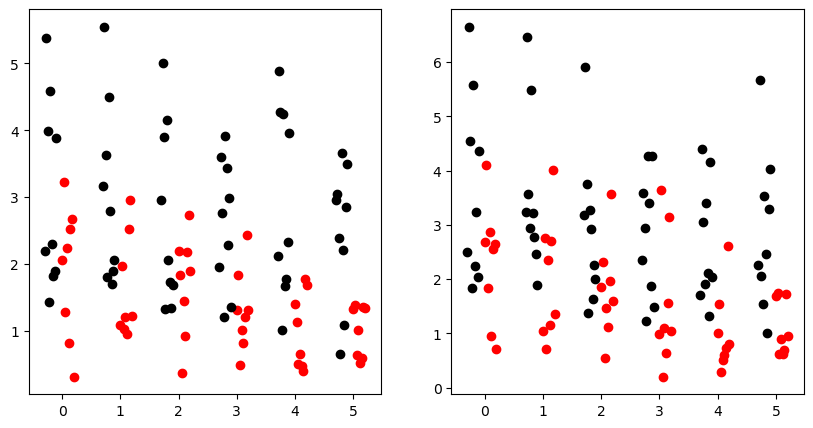

In [5]:
fig, ax = plt.subplots(1,2, figsize=[10,5])

for day in range(6):
    for ax_ind, lr in enumerate(('left', 'right')):
    
        ko = np.array(ko_lr[day][lr])
        ax[ax_ind].scatter(np.linspace(day,day+.2, num = ko.shape[0]),ko, color='red')

        ctrl = np.array(ctrl_lr[day][lr])
        ax[ax_ind].scatter(np.linspace(day-.3, day-.1, num = ctrl.shape[0]),ctrl, color='black')
    #     print(ko,ctrl)
        t,p = sp.stats.ranksums(ko,ctrl)
        print("%s day %d: t:%f, p:%f" % (lr, day,t,p))

/tmp/ipykernel_2437518/2354340833.py:55: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append({'mouse': mouse,
/tmp/ipykernel_2437518/2354340833.py:70: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append({'mouse': mouse,
/tmp/ipykernel_2437518/2354340833.py:70: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append({'mouse': mouse,
/tmp/ipykernel_2437518/2354340833.py:55: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df = df.append({'mouse': mouse,
/tmp/ipykernel_2437518/2354340833.py:55: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat ins

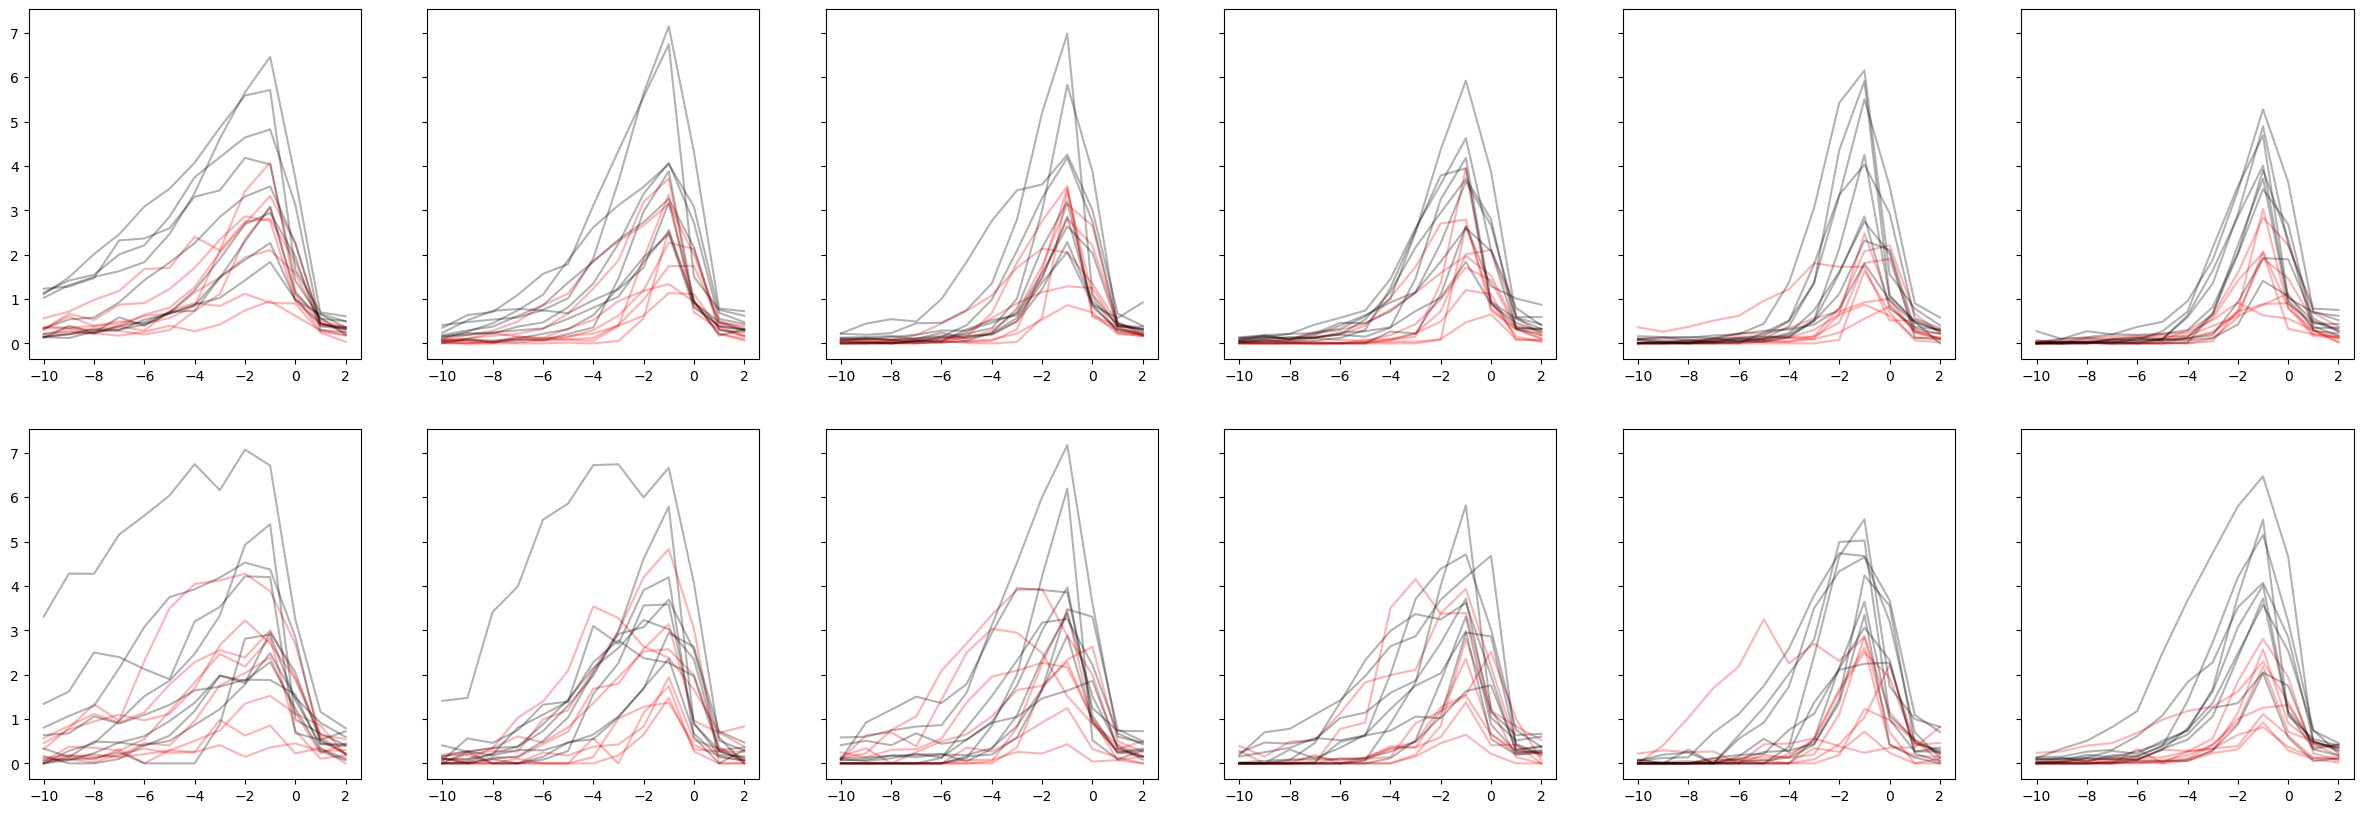

In [6]:

fig,ax = plt.subplots(2,6, figsize = [30, 10],sharey=True)


df = pd.DataFrame({'mouse':[],
                        'ko':[],
                        'day':[],
                        'day_norm': [],
                        'dz': [],
                        'ko_x_day': [],
                        'nov':[],
                        'ko_x_nov': [],
                        'lr': [],
                        'lickrate':[], 
                        'intercept': [],
                        })

key = 'nonconsum_licks'
if key in ('licks', 'nonconsum_licks'):
    alpha = dt
elif key in ('speed'):
    alpha = dt*10
else:
    alpha = 1.
ko_lr, ctrl_lr = {}, {}
for day in range(6):
    ko_lr[day] = {'fam':[],'nov':[]}
    
    x = np.arange(-10,3)
    for mouse in ko_mice:

        sess = u.load_vr_day(mouse,day, trial_mat_keys = ('licks','nonconsum_licks','licks_sum','speed'),verbose = False)
        bin_edges = sess.trial_matrices['bin_edges']
        for ax_ind, lr in enumerate([-1, 1]):
            trial_mask = sess.trial_info['LR']== lr
            
#             lick_mean = np.nanmean(sess.trial_matrices['licks_sum'][trial_mask,:].ravel())

#             mu = dt*np.nanmean(sess.trial_matrices['nonconsum_licks'][trial_mask,:], axis=0)
            
            mu = alpha*np.nanmean(sess.trial_matrices[key][trial_mask,:], axis=0)

            if sess.novel_arm ==-1:
                fam_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
                nov_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            elif sess.novel_arm == 1:
                fam_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]
                nov_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
            if lr == sess.novel_arm:
                ko_lr[day]['nov'].append(mu[nov_rzone_front-10:nov_rzone_front+3])
#                 ko_mu[day]['nov'].append(np.nanmean(mu[nov_rzone_front-3:nov_rzone_front]))
                
                _nov = np.nanmean(mu[nov_rzone_front-3:nov_rzone_front+1])
                ax[1,day].plot(x, mu[nov_rzone_front-10:nov_rzone_front+3],color='red', alpha = .3)
                df = df.append({'mouse': mouse, 
                                 'ko': 1, 
                                 'day': day,
                                 'day_norm': (day+1)/6.,
                                 'ko_x_day': (day+1)/6.,
                                 'nov': 1,
                                 'ko_x_nov': 1,
                                 'lr':ax_ind,
                                 'lickrate': _nov,
                                 'intercept': 1,
                                }, ignore_index=True)
            else:
                ko_lr[day]['fam'].append(mu[fam_rzone_front-10:fam_rzone_front+3])
                _fam = np.nanmean(mu[fam_rzone_front-3:fam_rzone_front+1])
                ax[0,day].plot(x, mu[fam_rzone_front-10:fam_rzone_front+3],color='red', alpha = .3)
                df = df.append({'mouse': mouse, 
                                 'ko': 1, 
                                 'day': day,
                                 'day_norm': (day+1)/6.,
                                 'ko_x_day': (day+1)/6.,
                                 'nov': 0,
                                 'ko_x_nov': 0,
                                 'lr': ax_ind,
                                 'lickrate': _fam,
                                 'intercept': 1,
                                }, ignore_index=True)
#                 ko_mu[day]['fam'].append(np.nanmean(mu[fam_rzone_front-3:fam_rzone_front]))
                
                    
                
       
                      

    ctrl_lr[day] = {'fam':[],'nov':[]}
    x = np.arange(-10,3)
    for mouse in ctrl_mice:
        sess = u.load_vr_day(mouse,day, trial_mat_keys = ('licks','nonconsum_licks','licks_sum','speed'),verbose = False)
        bin_edges = sess.trial_matrices['bin_edges']
        for ax_ind, lr in enumerate([-1, 1]):
            trial_mask = sess.trial_info['LR']== lr
#             lick_mean = np.nanmean(sess.trial_matrices['licks_sum'][trial_mask,:].ravel())

#             mu = dt*np.nanmean(sess.trial_matrices['nonconsum_licks'][trial_mask,:], axis=0)
            mu = alpha*np.nanmean(sess.trial_matrices[key][trial_mask,:], axis=0)

            if sess.novel_arm ==-1:

                fam_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
                nov_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            elif sess.novel_arm == 1:
                fam_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]
                nov_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]

            if lr == sess.novel_arm:
                ctrl_lr[day]['nov'].append(mu[nov_rzone_front-10:nov_rzone_front+3])
#                 ctrl_mu[day]['nov'].append(np.nanmean(mu[nov_rzone_front-3:nov_rzone_front]))
                _nov = np.nanmean(mu[nov_rzone_front-3:nov_rzone_front+1])
                ax[1,day].plot(x, mu[nov_rzone_front-10:nov_rzone_front+3],color='black', alpha = .3)
                df = df.append({'mouse': mouse, 
                                 'ko': 0, 
                                 'day': day,
                                 'day_norm': (day+1)/6.,
                                 'ko_x_day': 0,
                                 'nov': 1,
                                 'ko_x_nov': 0,
                                 'lr': ax_ind,
                                 'lickrate': _nov,
                                 'intercept': 1,
                                }, ignore_index=True)
            else:
                ctrl_lr[day]['fam'].append(mu[fam_rzone_front-10:fam_rzone_front+3])
#                 ctrl_mu[day]['fam'].append(np.nanmean(mu[fam_rzone_front-3:fam_rzone_front]))
                _fam = np.nanmean(mu[fam_rzone_front-3:fam_rzone_front+1])
                ax[0,day].plot(x, mu[fam_rzone_front-10:fam_rzone_front+3],color='black', alpha = .3)
                
                df = df.append({'mouse': mouse, 
                                 'ko': 0, 
                                 'day': day,
                                 'day_norm': (day+1)/6.,
                                 'ko_x_day': 0,
                                 'nov': 0,
                                 'ko_x_nov': 0,
                                 'lr': ax_ind,
                                 'lickrate': _fam,
                                 'intercept': 1,
                                }, ignore_index=True)
        
    

# for day in range(6):
#     for ax_ind, lr in enumerate(['fam', 'nov']):
#         arr = np.array(ko_lr[day][lr])
#         mu, sem = np.nanmean(arr,axis=0), sp.stats.sem(arr, axis=0, nan_policy='omit')
#         ax[ax_ind,day].fill_between(x, mu- sem, mu+sem,color='red', alpha = .3)

#         arr = np.array(ctrl_lr[day][lr])
#         mu, sem = np.nanmean(arr,axis=0), sp.stats.sem(arr, axis=0, nan_policy='omit')
#         ax[ax_ind, day].fill_between(x, mu- sem, mu+sem,color='black', alpha = .3)
#     #     ax[ax_ind].plot(x, np.array(ko_mu[lr]).T,color='red', alpha = .3)


    
#         ax[ax_ind, day].fill_betweenx([0,5], 0, 2, zorder=-1, color='purple',alpha=.3)
#         ax[ax_ind, day].fill_betweenx([0,5], 0, 2, zorder=-1, color='purple',alpha=.3)

#         ax[ax_ind, day].set_xlabel('Position')
#         ax[ax_ind, day].set_xlabel('Position')
#         ax[ax_ind, day].set_ylabel('Lick Rate')
#         ax[ax_ind, day].spines['top'].set_visible(False)
#         ax[ax_ind, day].spines['top'].set_visible(False)
#         ax[ax_ind, day].spines['right'].set_visible(False)
#         ax[ax_ind, day].spines['right'].set_visible(False)

# fig.savefig(os.path.join(fig_dir, 'famnov_lickrate_alldays.pdf'))



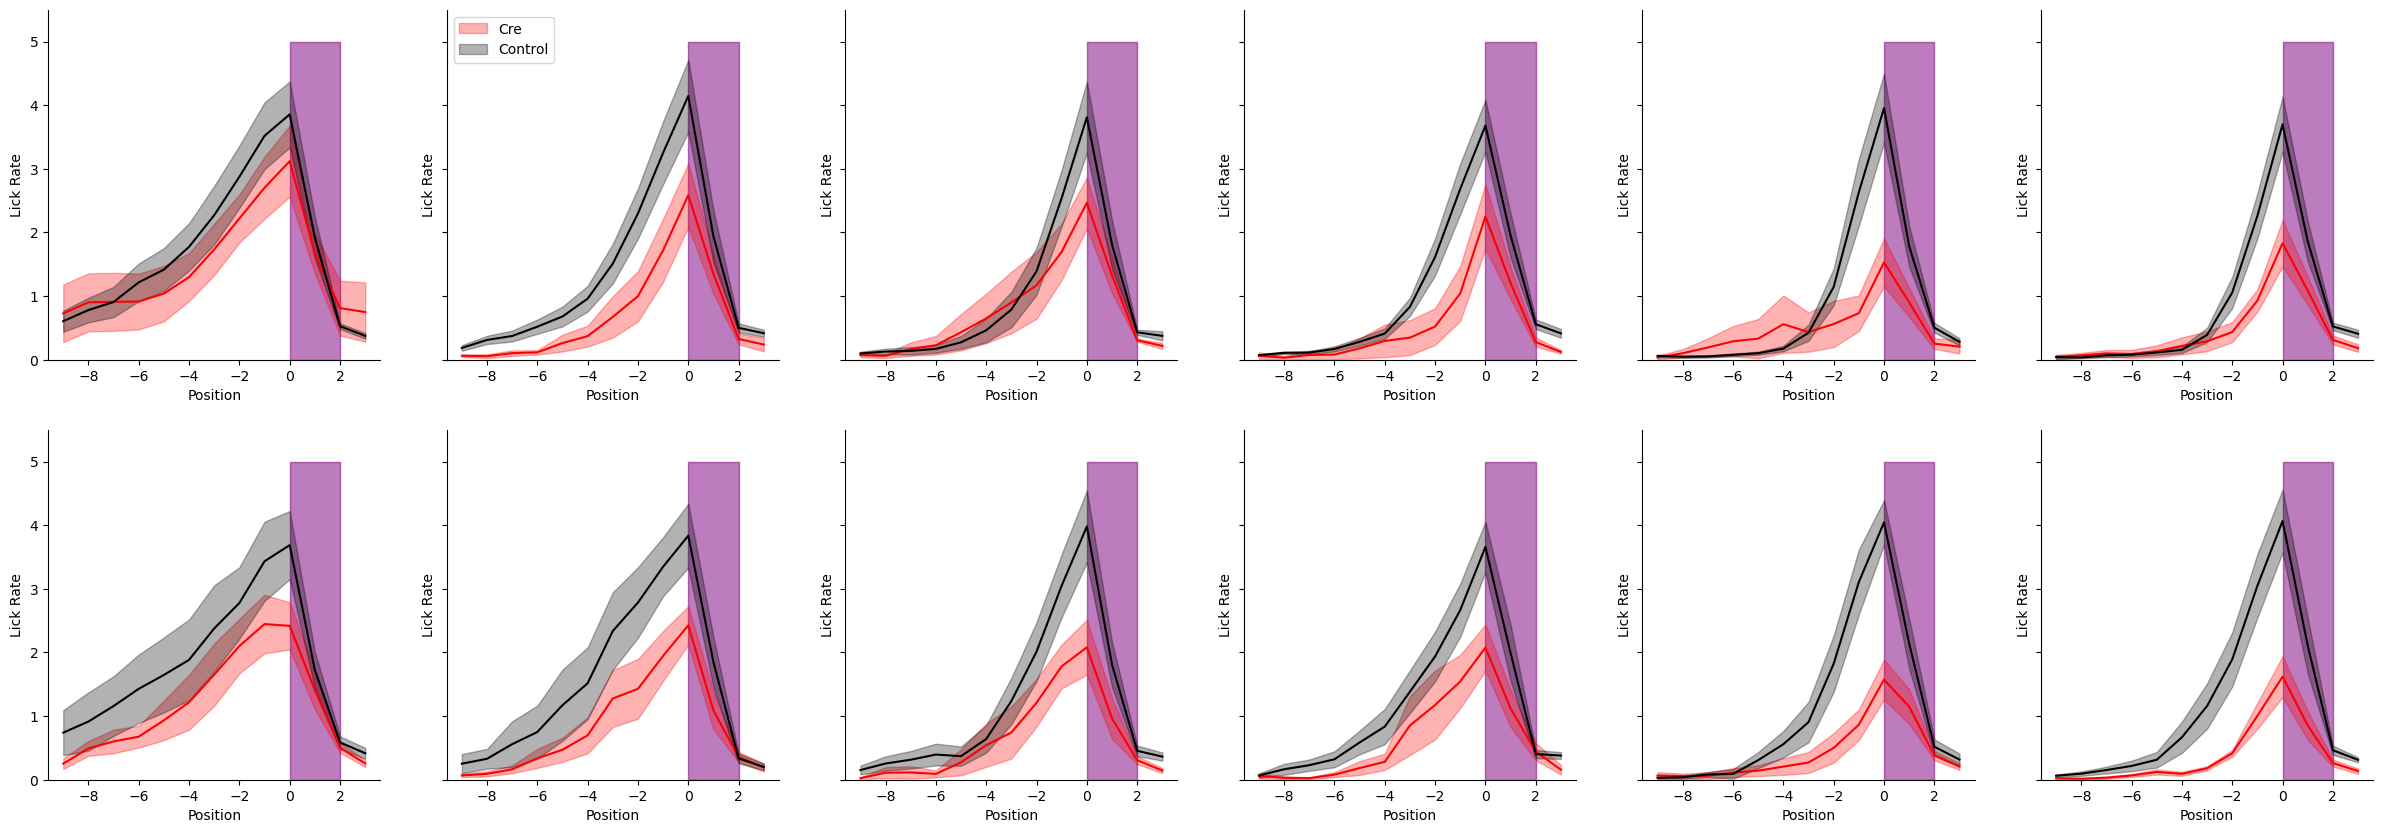

In [72]:
fig,ax = plt.subplots(2,6, figsize = [30, 10],sharey=True)


df = {'mouse':[],
      'ko':[],
      'day':[],
      'nov':[],
      'lickrate': [],
      }

key = 'nonconsum_licks'
if key in ('licks', 'nonconsum_licks'):
    alpha = dt
elif key in ('speed'):
    alpha = dt*10
else:
    alpha = 1.
ko_lr, ctrl_lr = {}, {}
for day in range(6):
    ko_lr[day] = {'fam':[],'nov':[]}
    
    x = np.arange(-10,3)
    for mouse in ko_mice:

        sess = u.load_vr_day(mouse,day, trial_mat_keys = ('licks','nonconsum_licks','licks_sum','speed'),verbose = False)
        bin_edges = sess.trial_matrices['bin_edges']
        for ax_ind, lr in enumerate([-1, 1]):
            trial_mask = sess.trial_info['LR']== lr
#             lick_mean = np.nanmean(sess.trial_matrices['licks_sum'][trial_mask,:].ravel())

#             mu = dt*np.nanmean(sess.trial_matrices['nonconsum_licks'][trial_mask,:], axis=0)
            
            mu = alpha*np.nanmean(sess.trial_matrices[key][trial_mask,:], axis=0)

            if sess.novel_arm ==-1:
                fam_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
                nov_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            elif sess.novel_arm == 1:
                fam_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]
                nov_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
            if lr == sess.novel_arm:
                ko_lr[day]['nov'].append(mu[nov_rzone_front-10:nov_rzone_front+3])
#                 ko_mu[day]['nov'].append(np.nanmean(mu[nov_rzone_front-3:nov_rzone_front]))
                
                _nov = np.nanmean(mu[nov_rzone_front-3:nov_rzone_front+1])
                df['mouse'].append(mouse)
                df['ko'].append('ko')
                df['day'].append(day)
                df['nov'].append('nov')
                df['lickrate'].append(_nov)
            
            
                # df = df.append({'mouse': mouse, 
                #                  'ko': 1, 
                #                  'day': day,
                #                  'day_norm': (day+1)/6.,
                #                  'ko_x_day': (day+1)/6.,
                #                  'nov': 1,
                #                  'ko_x_nov': 1,
                #                  'lr':ax_ind,
                #                  'lickrate': _nov,
                #                  'intercept': 1,
                #                 }, ignore_index=True)
            else:
                ko_lr[day]['fam'].append(mu[fam_rzone_front-10:fam_rzone_front+3])
                _fam = np.nanmean(mu[fam_rzone_front-3:fam_rzone_front+1])
                df['mouse'].append(mouse)
                df['ko'].append('ko')
                df['day'].append(day)
                df['nov'].append('fam')
                df['lickrate'].append(_fam)
                # df = df.append({'mouse': mouse, 
                #                  'ko': 1, 
                #                  'day': day,
                #                  'day_norm': (day+1)/6.,
                #                  'ko_x_day': (day+1)/6.,
                #                  'nov': 0,
                #                  'ko_x_nov': 0,
                #                  'lr': ax_ind,
                #                  'lickrate': _fam,
                #                  'intercept': 1,
                #                 }, ignore_index=True)
#                 ko_mu[day]['fam'].append(np.nanmean(mu[fam_rzone_front-3:fam_rzone_front]))
                
                    
                
    
                      

    ctrl_lr[day] = {'fam':[],'nov':[]}
    x = np.arange(-9,4)
    for mouse in ctrl_mice:
        sess = u.load_vr_day(mouse,day, trial_mat_keys = ('licks','nonconsum_licks','licks_sum','speed'),verbose = False)
        bin_edges = sess.trial_matrices['bin_edges']
        for ax_ind, lr in enumerate([-1, 1]):
            trial_mask = sess.trial_info['LR']== lr
#             lick_mean = np.nanmean(sess.trial_matrices['licks_sum'][trial_mask,:].ravel())

#             mu = dt*np.nanmean(sess.trial_matrices['nonconsum_licks'][trial_mask,:], axis=0)
            mu = alpha*np.nanmean(sess.trial_matrices[key][trial_mask,:], axis=0)

            if sess.novel_arm ==-1:

                fam_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
                nov_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            elif sess.novel_arm == 1:
                fam_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]
                nov_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]

            if lr == sess.novel_arm:
                ctrl_lr[day]['nov'].append(mu[nov_rzone_front-10:nov_rzone_front+3])
#                 ctrl_mu[day]['nov'].append(np.nanmean(mu[nov_rzone_front-3:nov_rzone_front]))
                _nov = np.nanmean(mu[nov_rzone_front-3:nov_rzone_front+1])
                df['mouse'].append(mouse)
                df['ko'].append('ctrl')
                df['day'].append(day)
                df['nov'].append('nov')
                df['lickrate'].append(_nov)
                # df = df.append({'mouse': mouse, 
                #                  'ko': 0, 
                #                  'day': day,
                #                  'day_norm': (day+1)/6.,
                #                  'ko_x_day': 0,
                #                  'nov': 1,
                #                  'ko_x_nov': 0,
                #                  'lr': ax_ind,
                #                  'lickrate': _nov,
                #                  'intercept': 1,
                #                 }, ignore_index=True)
            else:
                ctrl_lr[day]['fam'].append(mu[fam_rzone_front-10:fam_rzone_front+3])
#                 ctrl_mu[day]['fam'].append(np.nanmean(mu[fam_rzone_front-3:fam_rzone_front]))
                _fam = np.nanmean(mu[fam_rzone_front-3:fam_rzone_front+1])
                df['mouse'].append(mouse)
                df['ko'].append('ctrl')
                df['day'].append(day)
                df['nov'].append('fam')
                df['lickrate'].append(_fam)
                # df = df.append({'mouse': mouse, 
                #                  'ko': 0, 
                #                  'day': day,
                #                  'day_norm': (day+1)/6.,
                #                  'ko_x_day': 0,
                #                  'nov': 0,
                #                  'ko_x_nov': 0,
                #                  'lr': ax_ind,
                #                  'lickrate': _fam,
                #                  'intercept': 1,
                #                 }, ignore_index=True)
            
df = pd.DataFrame(df)
        
    

for day in range(6):
    for ax_ind, lr in enumerate(['fam', 'nov']):
        arr = np.array(ko_lr[day][lr])
        mu, sem = np.nanmean(arr,axis=0), sp.stats.sem(arr, axis=0, nan_policy='omit')
        ax[ax_ind,day].fill_between(x, mu- sem, mu+sem,color='red', alpha = .3, label='Cre')
        ax[ax_ind,day].plot(x, mu,color='red', alpha = 1)

        arr = np.array(ctrl_lr[day][lr])
        mu, sem = np.nanmean(arr,axis=0), sp.stats.sem(arr, axis=0, nan_policy='omit')
        ax[ax_ind, day].fill_between(x, mu- sem, mu+sem,color='black', alpha = .3, label='Control')
    #     ax[ax_ind].plot(x, np.array(ko_mu[lr]).T,color='red', alpha = .3)
        ax[ax_ind,day].plot(x, mu,color='black', alpha = 1)

    
        ax[ax_ind, day].fill_betweenx([0,5], 0, 2, zorder=-1, color='purple',alpha=.3)
        ax[ax_ind, day].fill_betweenx([0,5], 0, 2, zorder=-1, color='purple',alpha=.3)

        ax[ax_ind, day].set_xlabel('Position')
        ax[ax_ind, day].set_xlabel('Position')
        ax[ax_ind, day].set_ylabel('Lick Rate')
        ax[ax_ind, day].spines['top'].set_visible(False)
        ax[ax_ind, day].spines['top'].set_visible(False)
        ax[ax_ind, day].spines['right'].set_visible(False)
        ax[ax_ind, day].spines['right'].set_visible(False)
        ax[ax_ind, day].set_ylim([0,5.5])
ax[0,1].legend(loc = 'upper left')

fig.savefig(os.path.join(fig_dir, 'famnov_lickrate_alldays.pdf'))

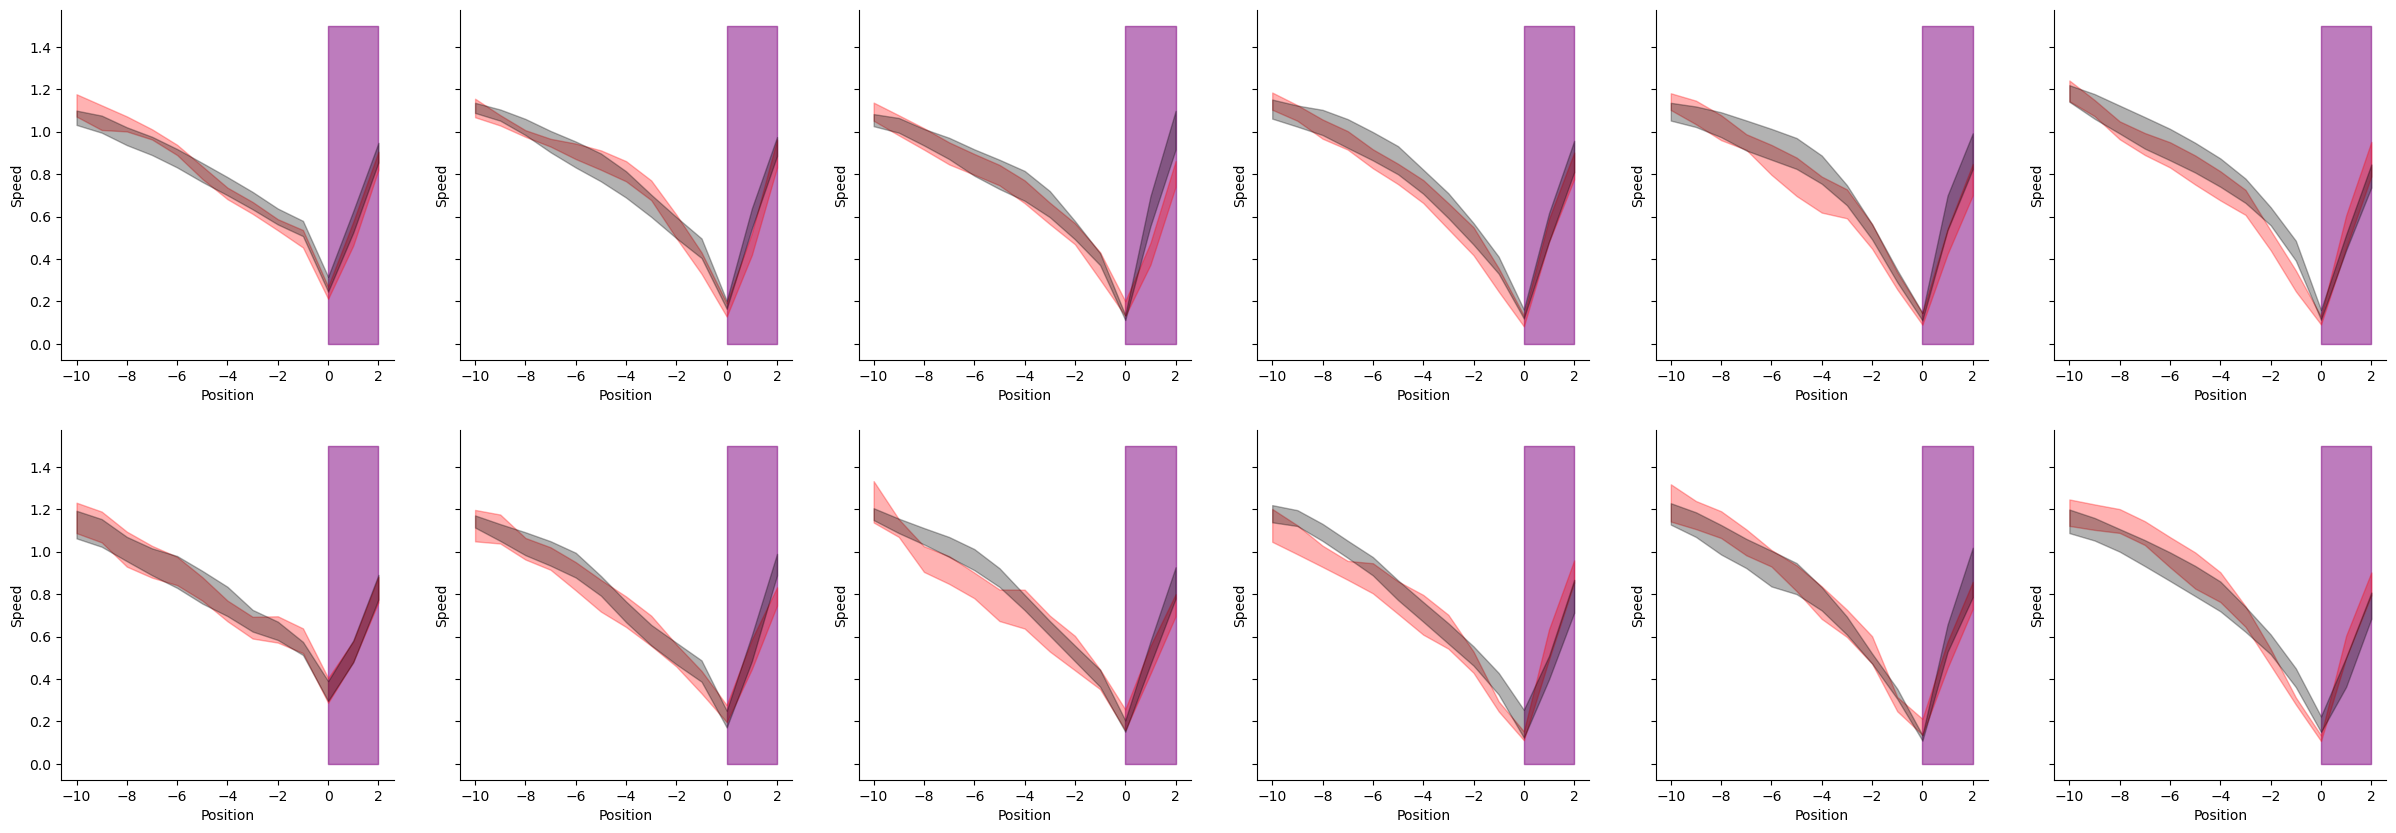

In [17]:



df = {'mouse':[],
      'ko':[],
      'day':[],
      'nov':[],
      'speed':[],
      'LR': [],
      'cov': []}

key = 'speed'
if key in ('licks', 'nonconsum_licks'):
    alpha = dt
elif key in ('speed'):
    alpha = dt*10
else:
    alpha = 1.
ko_lr, ctrl_lr = {}, {}
for day in range(6):
    ko_lr[day] = {'speed':{'fam':[],'nov':[]}, 'cov':{'fam':[], 'nov':[]}}
    
    x = np.arange(-10,3)
    for mouse in ko_mice:

        sess = u.load_vr_day(mouse,day, trial_mat_keys = ('licks','nonconsum_licks','licks_sum','speed'),verbose = False)
        bin_edges = sess.trial_matrices['bin_edges']
        for ax_ind, lr in enumerate([-1, 1]):
            trial_mask = sess.trial_info['LR']== lr
            df['LR'].append(lr)
            grand_mean = alpha*np.nanmean(sess.trial_matrices[key][trial_mask,:].ravel())
            std = np.nanstd(alpha*sess.trial_matrices[key][trial_mask,:]/grand_mean, axis=0)
            mu = np.nanmean(alpha*sess.trial_matrices[key][trial_mask,:]/grand_mean, axis=0) #/grandmean
            cov = std/mu
            # mu = 

            if sess.novel_arm ==-1:
                fam_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
                nov_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            elif sess.novel_arm == 1:
                fam_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]
                nov_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
            if lr == sess.novel_arm:
                ko_lr[day]['cov']['nov'].append(cov[nov_rzone_front-10:nov_rzone_front+3])
                ko_lr[day]['speed']['nov'].append(mu[nov_rzone_front-10:nov_rzone_front+3])
                # ko_mu[day]['nov'].append(np.nanmean(mu[nov_rzone_front-3:nov_rzone_front]))
                
                _mu = np.nanmean(mu[nov_rzone_front-3:nov_rzone_front])
                _cov = np.nanmean(cov[nov_rzone_front-3:nov_rzone_front])
                df['mouse'].append(mouse)
                df['ko'].append(True)
                df['day'].append(day)
                df['nov'].append(True)
                df['speed'].append(_mu)
                df['cov'].append(_cov)
                
            else:
                ko_lr[day]['cov']['fam'].append(cov[fam_rzone_front-10:fam_rzone_front+3])
                ko_lr[day]['speed']['fam'].append(mu[fam_rzone_front-10:fam_rzone_front+3])
                # _fam = np.nanmean(mu[fam_rzone_front-10:fam_rzone_front-1])
                
                _mu = np.nanmean(mu[fam_rzone_front-3:fam_rzone_front])
                _cov = np.nanmean(cov[fam_rzone_front-3:fam_rzone_front])
                df['mouse'].append(mouse)
                df['ko'].append(True)
                df['day'].append(day)
                df['nov'].append(False)
                df['speed'].append(_mu)
                df['cov'].append(_cov)
                
                # ko_mu[day]['fam'].append(np.nanmean(mu[fam_rzone_front-3:fam_rzone_front]))
                
                    
                
       
                      

    ctrl_lr[day] = {'speed':{'fam':[],'nov':[]}, 'cov':{'fam':[], 'nov':[]}}
    x = np.arange(-10,3)
    for mouse in ctrl_mice:
        sess = u.load_vr_day(mouse,day, trial_mat_keys = ('licks','nonconsum_licks','licks_sum','speed'),verbose = False)
        bin_edges = sess.trial_matrices['bin_edges']
        for ax_ind, lr in enumerate([-1, 1]):
            trial_mask = sess.trial_info['LR']== lr
#             lick_mean = np.nanmean(sess.trial_matrices['licks_sum'][trial_mask,:].ravel())
            df['LR'].append(lr)
            
#             mu = dt*np.nanmean(sess.trial_matrices['nonconsum_licks'][trial_mask,:], axis=0)
            grand_mean = alpha*np.nanmean(sess.trial_matrices[key][trial_mask,:].ravel())
            std = np.nanstd(alpha*sess.trial_matrices[key][trial_mask,:]/grand_mean, axis=0)
            mu = np.nanmean(alpha*sess.trial_matrices[key][trial_mask,:]/grand_mean, axis=0) #/grandmean
            cov = std/mu

            if sess.novel_arm ==-1:

                fam_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]
                nov_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]

            elif sess.novel_arm == 1:
                fam_rzone_front = np.argwhere((sess.rzone_early['tfront']<=bin_edges[1:])*(sess.rzone_early['tfront']>=bin_edges[:-1]))[0][0]
                nov_rzone_front = np.argwhere((sess.rzone_late['tfront']<=bin_edges[1:])*(sess.rzone_late['tfront']>=bin_edges[:-1]))[0][0]

            if lr == sess.novel_arm:
                ctrl_lr[day]['cov']['nov'].append(cov[nov_rzone_front-10:nov_rzone_front+3])
                ctrl_lr[day]['speed']['nov'].append(mu[nov_rzone_front-10:nov_rzone_front+3])

                

                _mu = np.nanmean(mu[nov_rzone_front-3:nov_rzone_front])
                _cov = np.nanmean(cov[nov_rzone_front-3:nov_rzone_front])
                df['mouse'].append(mouse)
                df['ko'].append(False)
                df['day'].append(day)
                df['nov'].append(True)
                df['speed'].append(_mu)
                df['cov'].append(_cov)
                
            else:
                ctrl_lr[day]['cov']['fam'].append(cov[fam_rzone_front-10:fam_rzone_front+3])
                ctrl_lr[day]['speed']['fam'].append(mu[fam_rzone_front-10:fam_rzone_front+3])

                _mu = np.nanmean(mu[fam_rzone_front-3:fam_rzone_front])
                _cov = np.nanmean(cov[fam_rzone_front-3:fam_rzone_front])
                df['mouse'].append(mouse)
                df['ko'].append(False)
                df['day'].append(day)
                df['nov'].append(False)
                df['speed'].append(_mu)
                df['cov'].append(_cov)
        
    
df = pd.DataFrame(df)

# normalized speed
fig,ax = plt.subplots(2,6, figsize = [30, 10],sharey=True)
for day in range(6):
    for ax_ind, lr in enumerate(['fam', 'nov']):
        arr = np.array(ko_lr[day]['speed'][lr])
        mu, sem = np.nanmean(arr,axis=0), sp.stats.sem(arr, axis=0, nan_policy='omit')
        ax[ax_ind,day].fill_between(x, mu- sem, mu+sem,color='red', alpha = .3)

        arr = np.array(ctrl_lr[day]['speed'][lr])
        mu, sem = np.nanmean(arr,axis=0), sp.stats.sem(arr, axis=0, nan_policy='omit')
        ax[ax_ind, day].fill_between(x, mu- sem, mu+sem,color='black', alpha = .3)
   


    
        ax[ax_ind, day].fill_betweenx([0,1.5], 0, 2, zorder=-1, color='purple',alpha=.3)
        ax[ax_ind, day].fill_betweenx([0,1.5], 0, 2, zorder=-1, color='purple',alpha=.3)

        ax[ax_ind, day].set_xlabel('Position')
        ax[ax_ind, day].set_xlabel('Position')
        ax[ax_ind, day].set_ylabel('Speed')
        ax[ax_ind, day].spines['top'].set_visible(False)
        ax[ax_ind, day].spines['top'].set_visible(False)
        ax[ax_ind, day].spines['right'].set_visible(False)
        ax[ax_ind, day].spines['right'].set_visible(False)
        
        
        
# fig,ax = plt.subplots(2,6, figsize = [30, 10],sharey=True)
# for day in range(6):
#     for ax_ind, lr in enumerate(['fam', 'nov']):
#         arr = np.array(ko_lr[day]['cov'][lr])
#         mu, sem = np.nanmean(arr,axis=0), sp.stats.sem(arr, axis=0, nan_policy='omit')
#         ax[ax_ind,day].fill_between(x, mu- sem, mu+sem,color='red', alpha = .3)

#         arr = np.array(ctrl_lr[day]['cov'][lr])
#         mu, sem = np.nanmean(arr,axis=0), sp.stats.sem(arr, axis=0, nan_policy='omit')
#         ax[ax_ind, day].fill_between(x, mu- sem, mu+sem,color='black', alpha = .3)
   


    
#         ax[ax_ind, day].fill_betweenx([0,1.5], 0, 2, zorder=-1, color='purple',alpha=.3)
#         ax[ax_ind, day].fill_betweenx([0,1.5], 0, 2, zorder=-1, color='purple',alpha=.3)

#         ax[ax_ind, day].set_xlabel('Position')
#         ax[ax_ind, day].set_xlabel('Position')
#         ax[ax_ind, day].set_ylabel('Speed COV')
#         ax[ax_ind, day].spines['top'].set_visible(False)
#         ax[ax_ind, day].spines['top'].set_visible(False)
#         ax[ax_ind, day].spines['right'].set_visible(False)
#         ax[ax_ind, day].spines['right'].set_visible(False)

        

fig_dir = 'C:/Users/esay/data/Stx3/YMazeResults/'
fig.savefig(os.path.join(fig_dir, 'famnov_speedCOV_alldays.pdf'))

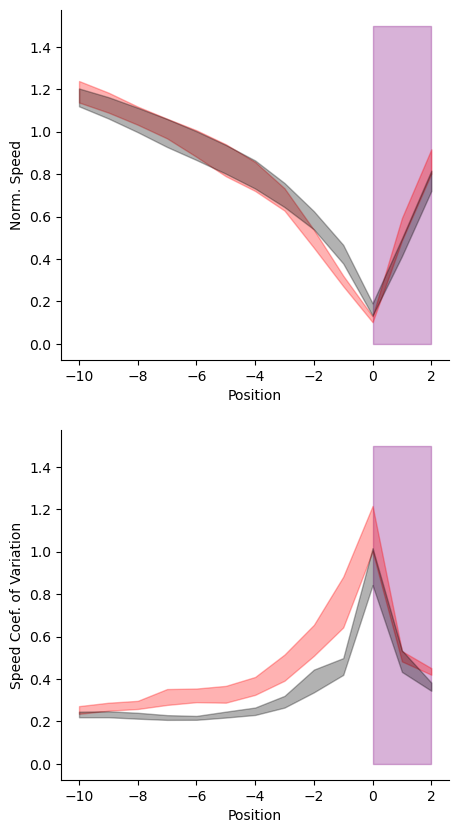

In [65]:
fig,ax = plt.subplots(2,1, figsize = [5, 10],sharey=True)
day = 5
x = np.arange(-10,3)




arr = np.concatenate((np.array(ko_lr[day]['speed']['fam'])[:,:,np.newaxis], np.array(ko_lr[day]['speed']['nov'])[:, :, np.newaxis]), axis=-1)
arr = arr.mean(axis=-1)
mu, sem = np.nanmean(arr,axis=0), sp.stats.sem(arr, axis=0, nan_policy='omit')

ax[0].fill_between(x, mu- sem, mu+sem,color='red', alpha = .3)

arr = np.concatenate((np.array(ctrl_lr[day]['speed']['fam'])[:,:,np.newaxis], np.array(ctrl_lr[day]['speed']['nov'])[:, :, np.newaxis]), axis=-1)
arr = arr.mean(axis=-1)
mu, sem = np.nanmean(arr,axis=0), sp.stats.sem(arr, axis=0, nan_policy='omit')

ax[0].fill_between(x, mu- sem, mu+sem,color='black', alpha = .3)
ax[0].fill_betweenx([0,1.5], 0, 2, zorder=-1, color='purple',alpha=.3)

ax[0].set_ylabel('Norm. Speed')
ax[0].set_xlabel('Position')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)


arr = np.concatenate((np.array(ko_lr[day]['cov']['fam'])[:,:,np.newaxis], np.array(ko_lr[day]['cov']['nov'])[:, :, np.newaxis]), axis=-1)
arr = arr.mean(axis=-1)
mu, sem = np.nanmean(arr,axis=0), sp.stats.sem(arr, axis=0, nan_policy='omit')

ax[1].fill_between(x, mu- sem, mu+sem,color='red', alpha = .3)

arr = np.concatenate((np.array(ctrl_lr[day]['cov']['fam'])[:,:,np.newaxis], np.array(ctrl_lr[day]['cov']['nov'])[:, :, np.newaxis]), axis=-1)
arr = arr.mean(axis=-1)
mu, sem = np.nanmean(arr,axis=0), sp.stats.sem(arr, axis=0, nan_policy='omit')

ax[1].fill_between(x, mu- sem, mu+sem,color='black', alpha = .3)

ax[1].fill_betweenx([0,1.5], 0, 2, zorder=-1, color='purple',alpha=.3)

ax[1].set_ylabel('Speed Coef. of Variation')
ax[1].set_xlabel('Position')
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

fig.savefig(os.path.join(fig_dir, 'day6_normspeed_COV.pdf'))

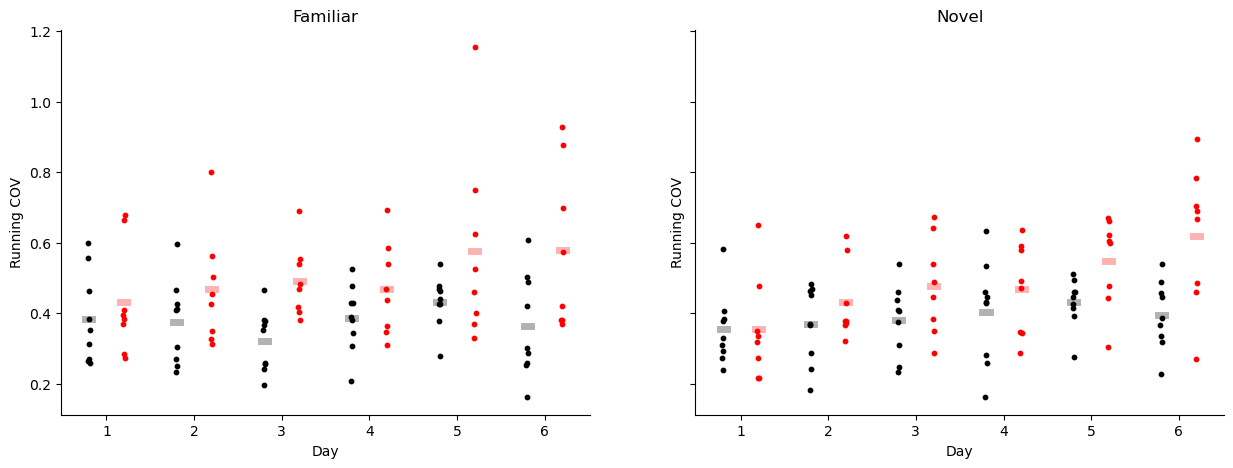

In [60]:
fig, ax = plt.subplots(1,2, figsize=[15,5], sharey=True)

lw = 5
s = 10
key = 'cov'
for day in range(6):
    
    mask = (df['ko']==False) & (df['day']==day) & (df['nov']==False)
    lr = df[key].loc[mask]._values
    ax[0].scatter(5*day -1 + np.linspace(-0.05, 0.05, num=lr.shape[0]), lr, color='black', s=s)
    ax[0].plot(5*day -1 + np.array([-0.2, .2]), lr.mean()*np.ones([2,]), color='black', linewidth=lw,alpha = .3)
    
    mask = (df['ko']==False) & (df['day']==day) & (df['nov']==True)
    lr = df[key].loc[mask]._values
    ax[1].scatter(5*day -1 + np.linspace(-0.05, 0.05, num=lr.shape[0]), lr, color='black', s=s, alpha = 1)
    ax[1].plot(5*day -1 + np.array([-0.2, .2]), lr.mean()*np.ones([2,]), color='black', linewidth=lw,alpha = .3)
    
    mask = (df['ko']==True) & (df['day']==day) & (df['nov']==False)
    lr = df[key].loc[mask]._values
    ax[0].scatter(5*day +1 + np.linspace(-0.05, 0.05, num=lr.shape[0]), lr, color='red', s=s)
    ax[0].plot(5*day + 1 + np.array([-0.2, .2]), lr.mean()*np.ones([2,]), color='red', linewidth=lw,alpha = .3)
    
    mask = (df['ko']==True) & (df['day']==day)& (df['nov']==True)
    lr = df[key].loc[mask]._values
    ax[1].scatter(5*day +1 + np.linspace(-0.05, 0.05, num=lr.shape[0]), lr, color='red', s=s, alpha=1)
    ax[1].plot(5*day + 1 + np.array([-0.2, .2]), lr.mean()*np.ones([2,]), color='red', linewidth=lw,alpha = .3)
    
ax[0].set_title('Familiar')
ax[1].set_title('Novel')
    
for a in range(2):

    ax[a].set_xticks(np.arange(0,6*5,5))
    ax[a].set_xticklabels([x for x in range(1,7)])

    ax[a].spines['top'].set_visible(False)
    ax[a].spines['right'].set_visible(False)

    ax[a].set_ylabel('Running COV')
    ax[a].set_xlabel('Day')

fig.savefig(os.path.join(fig_dir, 'famnov_speed_COV_summary.pdf'))

### Lick Raster

In [234]:

def plot_lick_raster_ES(sess, x, mat, day =0, ax=None, fig=None, vals = None, smooth=True ,arm=None, label=True, sig=0.5, cmap='winter'):

    if ax is None:
        fig, axs = plt.subplots(2, 2, figsize=(3, 3), sharex=True,
                            gridspec_kw={'height_ratios':[3,1]})
        ax_raster, ax_summary = axs
    elif isinstance(ax, (tuple, list)):
        ax_raster, ax_summary = ax

    xpos = sess.vr_data['posx']
    ntrials = mat.shape[0]
    mouse = sess.mouse

    trial_types = sess.trial_info['LR']

    # plot reward zones
    if arm ==1:
        ax_raster.axvspan(sess.rzone_early['tfront']*10, sess.rzone_early['tback']*10, color='blue', alpha=0.1)#, label='L zone')
        ax_summary.axvspan(sess.rzone_early['tfront']*10, sess.rzone_early['tback']*10, color='blue', alpha=0.1)#, label='L zone')
    elif arm == -1:
        ax_raster.axvspan(sess.rzone_late['tfront']*10, sess.rzone_late['tback']*10, color='green', alpha=0.1)# label='R zone')
        ax_summary.axvspan(sess.rzone_late['tfront']*10, sess.rzone_late['tback']*10, color='green', alpha=0.1)# label='R zone')
    else:
        ax_raster.axvspan(sess.rzone_early['tfront']*10, sess.rzone_early['tback']*10, color='blue', alpha=0.1)#, label='L zone')
        ax_raster.axvspan(sess.rzone_late['tfront']*10, sess.rzone_late['tback']*10, color='green', alpha=0.1)
        ax_summary.axvspan(sess.rzone_early['tfront']*10, sess.rzone_early['tback']*10, color='blue', alpha=0.1)#, label='L zone')
        ax_summary.axvspan(sess.rzone_late['tfront']*10, sess.rzone_late['tback']*10, color='green', alpha=0.1)
        
    cm = matplotlib.colormaps.get_cmap(cmap)
    # cm = LinearSegmentedColormap.from_list('MgK', ['magenta', 'white', 'black'])
    
    if smooth:
        mat = gaussian_filter1d(mat, sig, axis=1)
        
    # convert to NaN for clean plots
    # mat[mat==0]=np.nan

    #find ommission trials
    # omis = ~(np.nansum(sess.trial_matrices['rewards'],axis=-1)>0)
    stx.behavior.trial_metrics.get_probes_and_omissions(sess)
    omis = sess.trial_info['probes'] 
    # omis = omis[::-1]
    
    
    # for ind, trial_id in enumerate(np.arange(mat.shape[0] - 1, -1, -1)):
    #     if omis[ind]:
    #         ax_raster.fill_between(x, mat[ind, :] + trial_id, y2=trial_id, color='magenta',linewidth=0)#, edgecolor='hotpink')
    #     else:
    #         ax_raster.fill_between(x, mat[ind, :] + trial_id, y2=trial_id,
    #                     color=cm(np.float64(vals[ind])), linewidth=0)

    n_total = 140  # or sess.trial_info.shape[0] if consistent
    n_present = mat.shape[0]
    n_missing = n_total - n_present
    
    # Create aligned y indices (top-down)
    y_indices = np.arange(n_total - 1, -1, -1)
    
    for i in range(n_present):
        trial_id = y_indices[i]
        if omis[i]:
            ax_raster.fill_between(x, mat[i, :] + trial_id, y2=trial_id,
                                   color='magenta', linewidth=0)
        else:
            ax_raster.fill_between(x, mat[i, :] + trial_id, y2=trial_id,
                                   color=cm(np.float64(vals[i])), linewidth=0)



    if label:
        ax_raster.set_ylabel('Trials')
    # formatting
    ax_raster.spines[['top', 'right']].set_visible(False)
    ax_raster.set_title(f"{mouse} Day: {day+1}")
    ax_raster.set_ylim(top=140, bottom=0)
    # ax_raster.invert_yaxis()
    
    yticks = np.arange(0, 140, 20)
    ax_raster.set_yticks(yticks)
    ax_raster.set_yticklabels((140 - yticks).astype(int))
    # ax_raster.set_xlabel('Pos (cm)')


    trial_types = np.array(trial_types)

    # left trials
    left_mask = trial_types == -1
    if left_mask.sum() > 0:
        mean_left = mat[left_mask].mean(axis=0)
        sem_left = mat[left_mask].std(axis=0) / np.sqrt(left_mask.sum())
        ax_summary.plot(x, mean_left, color="blue", lw=1.5, label="Left")
        ax_summary.fill_between(x, mean_left - sem_left, mean_left + sem_left,
                                color="blue", alpha=0.3)

    # right trials
    right_mask = trial_types == 1
    if right_mask.sum() > 0:
        mean_right = mat[right_mask].mean(axis=0)
        sem_right = mat[right_mask].std(axis=0) / np.sqrt(right_mask.sum())
        ax_summary.plot(x, mean_right, color="green", lw=1.5, label="Right")
        ax_summary.fill_between(x, mean_right - sem_right, mean_right + sem_right,
                                color="green", alpha=0.3)

    ax_summary.set_ylabel("Lick rate")
    ax_summary.set_xlabel("Pos (cm)")
    ax_summary.spines[['top','right']].set_visible(False)



    return fig, ax


In [25]:
fig_dir = 'C:/Users/esay/data/Stx3/YMazeResults/behavior/lick_analysis'

{'date': '18_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '20_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 2}
{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 5}


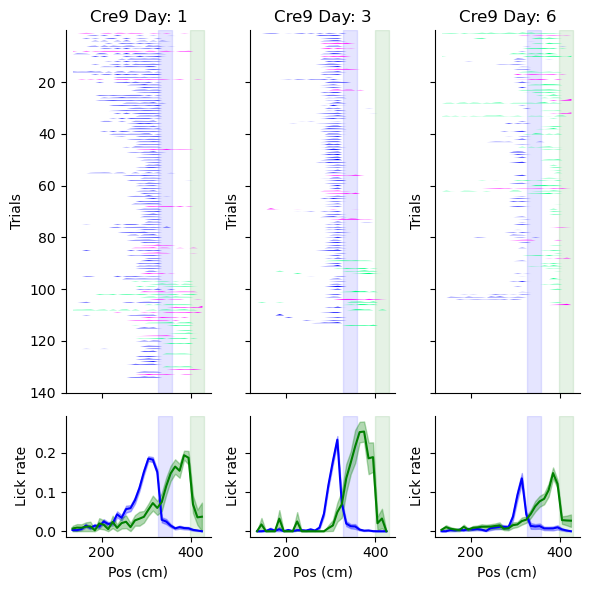

In [235]:
days =[0,2,5]
mouse = ko_mice[6]
# mouse = '4467975.1'
fig,axs = plt.subplots(2, len(days), figsize=(2*len(days), 6), sharey = 'row',
                      gridspec_kw = {"height_ratios":[3,1]},sharex='col')



for i, day in enumerate(days):
    sess = u.load_vr_day(mouse,day)
    sess.add_timeseries(rewards=sess.vr_data['reward'])
    sess.add_pos_binned_trial_matrix('rewards')
    x = sess.trial_matrices['bin_centers']
    mat = sess.trial_matrices['licks']
    vals = sess.trial_info['LR']
    plot_lick_raster_ES(sess, x*10,mat ,day = day,ax=(axs[0,i],axs[1,i]),fig=fig,smooth = False, vals = vals)
fig.tight_layout()
# fig.savefig(os.path.join(fig_dir, f"lick_raster_and_summary{mouse}.pdf"))

### Lick accuracy 

In [239]:
def get_lick_metrics(sess):
    
    stx.behavior.trial_metrics.antic_consum_licks(sess)
    stx.behavior.trial_metrics.get_probes_and_omissions(sess)
    stx.behavior.trial_metrics.single_trial_lick_metrics(sess)

    return sess

In [240]:
def lick_metrics(sess):
    reward_mask = sess.vr_data['reward']._values > 0
    reward_start = np.argwhere(reward_mask).ravel() - 1
    # reward_end = (reward_start + int(2 * sess.scan_info['frame_rate'])).astype(np.int)
    reward_end = (reward_start + int(2 * 50)).astype(np.int64)
    
    consum_mask = np.zeros(reward_mask.shape) > 0
    for (start, end) in zip(reward_start, reward_end):
        consum_mask[start:end] = True
    
    antic_licks = np.copy(sess.vr_data['lick']._values)
    antic_licks[consum_mask] = 0
    
    nonconsum_speed = np.copy(sess.vr_data['dz']._values)
    nonconsum_speed[consum_mask] = np.nan
    
    sess.add_timeseries(antic_licks=antic_licks,
                        licks=sess.vr_data['lick']._values,
                        speed=sess.vr_data['dz']._values,
                        antic_speed=nonconsum_speed)
    sess.add_pos_binned_trial_matrix(('antic_licks', 'speed', 'antic_speed'), 't', mat_only=True)
    
    antic_lick_positions = np.zeros(sess.timeseries['licks'].shape) * np.nan
    antic_lick_mask = sess.timeseries['antic_licks'] > 0
    antic_lick_positions[antic_lick_mask] = sess.vr_data['t']._values[antic_lick_mask.ravel()]
    sess.add_timeseries(antic_lick_positions=antic_lick_positions)

    bin_lower_edges = sess.trial_matrices['bin_edges'][:-1]

    lr_early = np.nanmean(sess.trial_matrices['antic_licks'][:, (bin_lower_edges >= sess.rzone_early['t_antic']) & (
            bin_lower_edges < sess.rzone_early['tfront'] + 2)], axis=-1)
    lr_early /= np.nanmean(sess.trial_matrices['antic_licks'].ravel())
    lr_late = np.nanmean(sess.trial_matrices['antic_licks'][:, (bin_lower_edges >= sess.rzone_late['t_antic']) & (
            bin_lower_edges < sess.rzone_late['tfront'] + 2)], axis=-1)
    lr_late /= np.nanmean(sess.trial_matrices['antic_licks'].ravel())
    #     print(lr_early,lr_late)
    lr_d = (lr_early - lr_late) / (lr_early + lr_late + 1E-3)
    
    stem_speed = np.nanmean(sess.trial_matrices['antic_speed'][:,
                            sess.trial_matrices['bin_edges'][:-1] < sess.rzone_early['t_antic']].ravel())
    arm_speed = np.nanmean(
        sess.trial_matrices['antic_speed'][:, sess.trial_matrices['bin_edges'][:-1] > sess.rzone_early['t_antic']],
        axis=-1)
    arm_speed_norm = arm_speed / stem_speed
    
    accuracy = np.zeros([sess.trial_start_inds.shape[0], ])
    err = np.zeros([sess.trial_start_inds.shape[0], ])
    mean = np.zeros([sess.trial_start_inds.shape[0], ]) * np.nan
    var = np.zeros([sess.trial_start_inds.shape[0], ])
    
    for trial, (start, stop, lr) in enumerate(
            zip(sess.trial_start_inds, sess.teleport_inds, sess.trial_info['LR'])):



        pos = sess.vr_data['t'].iloc[start:stop]
        licks = sess.timeseries['antic_licks'][0, start:stop]
        lick_pos = sess.timeseries['antic_lick_positions'][0, start:stop]
        if lr == 1:
            rzone = (sess.rzone_late['t_antic'], sess.rzone_late['tfront'] + 2)
            tfront = sess.rzone_late['tfront']

        else:
            rzone = (sess.rzone_early['t_antic'], sess.rzone_early['tfront'] + 2)
            tfront = sess.rzone_late['tfront']

        rzone_mask = (pos >= rzone[0]) & (pos <= rzone[1])

        # Lick accuracy: licks in reward zone / total non-consummatory licks
        accuracy[trial] = licks[rzone_mask].sum() / (licks.sum() + 1E-3)

        # lick position variance
        if licks.sum() > 1:
            mean[trial] = np.nanmedian(lick_pos) / tfront
            var[trial] = np.nanstd(lick_pos)
            err[trial] = np.nanmean(np.abs((lick_pos - tfront) / tfront))

    sess.trial_info.update({'lickrate_rz_early': lr_early,
                            'lickrate_rz_late': lr_late,
                            'lickrate_dprime': lr_d,
                            'lick_acc': accuracy,
                            'lick_meanpos': mean,
                            'lick_varpos': var,
                            'lick_err': err,
                            'arm_speed': arm_speed,
                            'arm_speed_norm': arm_speed_norm
    
                            })
    return sess

In [244]:
def get_concat_sess(mouse, day, ko):
    if ko=='CTRL':
        d = ctrl_sessions[mouse][day]
    else:
        d = ko_sessions[mouse][day]
    sess_list = []
    vr_data = []
    for i, sess_info in enumerate(d):
        date, scene, sess_no, scan = sess_info['date'], sess_info['scene'], sess_info['session'], sess_info['scan']
        pkldir = os.path.join('C://Users/esay/data/Stx3/YMazeSessPkls/', mouse,  date, f'{scene}_{sess_no}.pkl')
        
        _sess = stx.session.YMazeSession.from_file(pkldir, verbose=False)
        _sess = get_lick_metrics(_sess)

        sess_list.append(_sess)
        print(sess_list)
        
        data = _sess.vr_data
        df = data.copy()

        vr_data.append(df)
    vr = pd.concat(vr_data, ignore_index = True)
    sess = stx.session.ConcatYMazeSession(sess_list, None, day_inds=[0 for i in range(len(d))], trial_info_keys = ['LR', 'block_number', 'lick_acc'],
                                          trial_mat_keys=('speed','antic_licks'),
                                          timeseries_keys=('licks', 'speed','antic_licks'),
                                          run_place_cells=False)
    sess.vr_data = vr
    print(len(sess.vr_data))
    
    return sess


{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


c:\users\esay\repos\twoputils\TwoPUtils\spatial_analyses.py:74: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)


{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 0}


c:\users\esay\repos\twoputils\TwoPUtils\spatial_analyses.py:74: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)


{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': -1, 'ravel_ind': 0}


...

{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 6, 'novel_arm': -1, 'ravel_ind': 5}


c:\users\esay\repos\twoputils\TwoPUtils\spatial_analyses.py:74: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)


{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 5}


c:\users\esay\repos\twoputils\TwoPUtils\spatial_analyses.py:74: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)


{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 5}


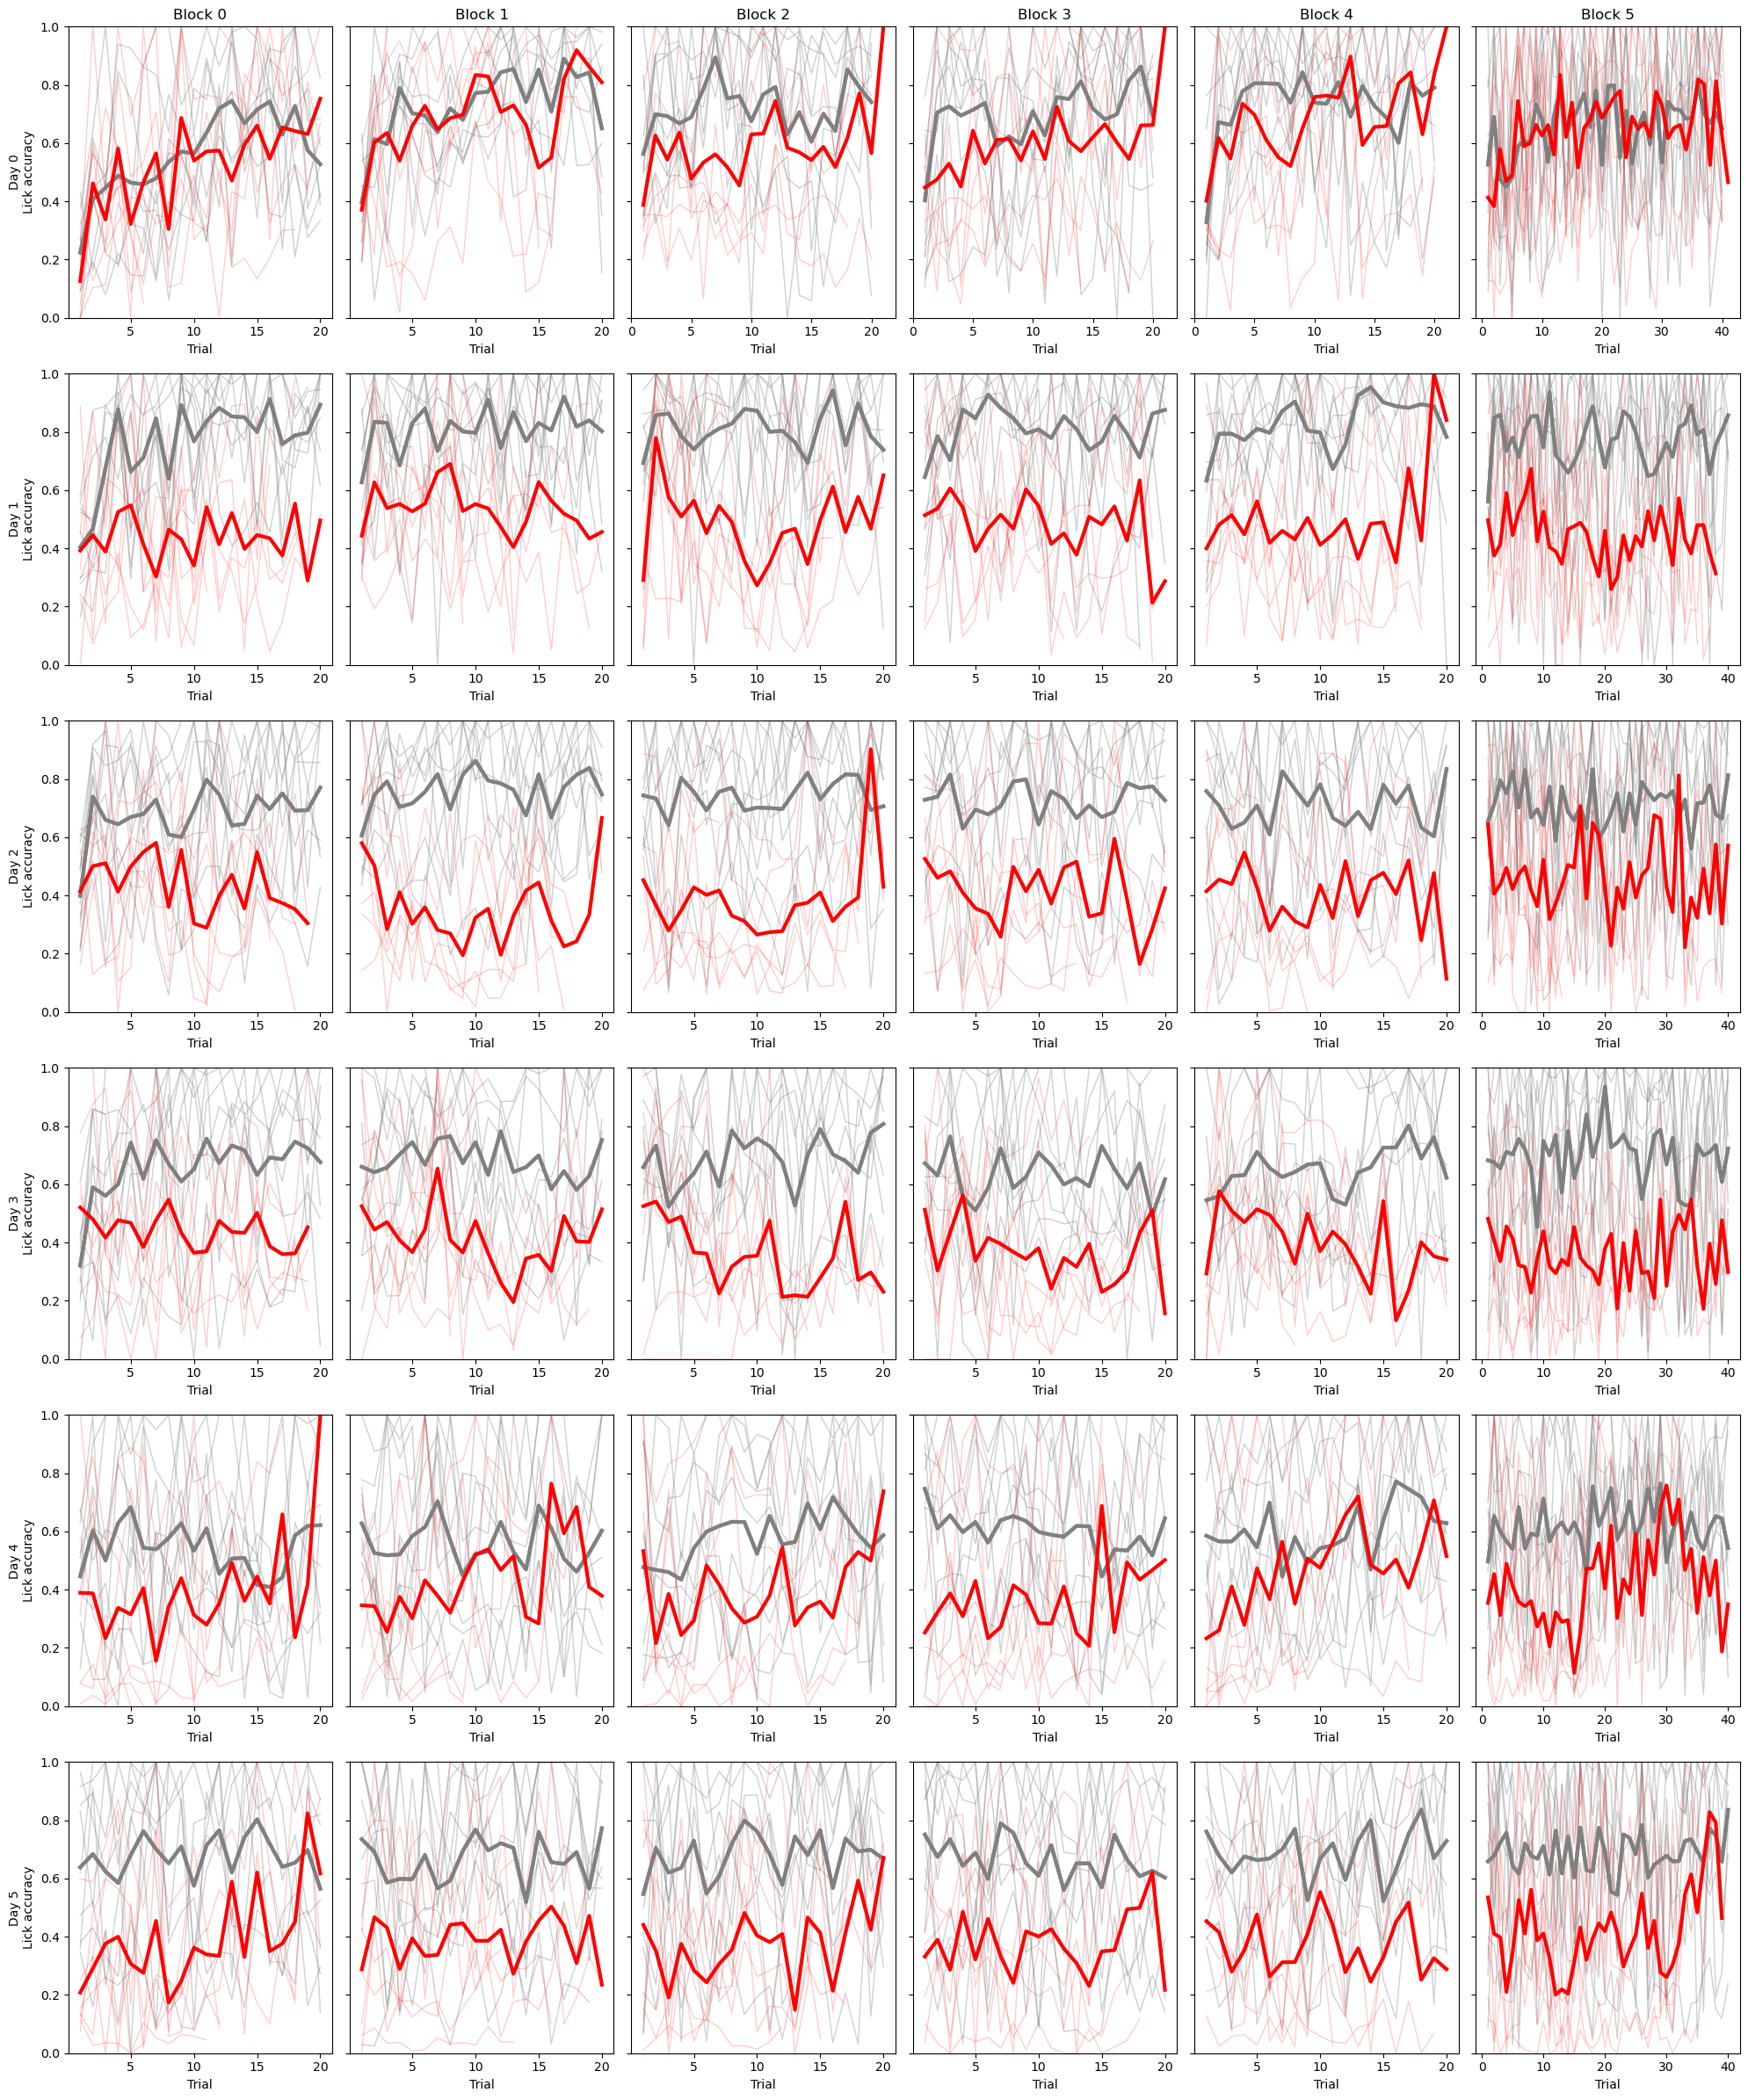

In [245]:

days = range(6)  
blocks = [0,1, 2, 3, 4, 5]

fig, axes = plt.subplots(len(days), len(blocks), figsize=(20, 4*len(days)), sharey=True)

for i, day in enumerate(days):
    all_data = {'ko': [], 'ctrl': []}

    for group, mice in zip(['CTRL','KO'], [ctrl_mice, ko_mice]):
        for mouse in mice:
            
            sess = u.load_vr_day(mouse, day)

            if isinstance(sess, stx.session.ConcatYMazeSession):
                sess = get_concat_sess(mouse, day, group)
            else:
                sess = lick_metrics(sess)
            
    
            for t in blocks:
                block_mask = sess.trial_info['block_number'] == t
                _lick_acc = np.asarray(sess.trial_info['lick_acc'])[block_mask]
    
                if mouse in ko_mice:
                    all_data['ko'].append((t, _lick_acc))
                elif mouse in ctrl_mice:
                    all_data['ctrl'].append((t, _lick_acc))
    
        for j, t in enumerate(blocks):
            ax = axes[i, j] if len(days) > 1 else axes[j]
    
            for block, arr in all_data['ctrl']:
                if block == t:
                    ax.plot(np.arange(1, len(arr)+1), arr, color='grey', alpha=0.2, lw=1)
            for block, arr in all_data['ko']:
                if block == t:
                    ax.plot(np.arange(1, len(arr)+1), arr, color='red', alpha=0.2, lw=1)
    
            # group mean
            max_trials = 0
            for group in ['ctrl', 'ko']:
                group_data = [arr for block, arr in all_data[group] if block == t]
                if group_data:
                    max_trials = max(max_trials, max(len(arr) for arr in group_data))
    
            for group, col in zip(['ctrl', 'ko'], ['grey', 'red']):
                group_data = [arr for block, arr in all_data[group] if block == t]
                if not group_data:
                    continue
                mean_vals = []
                for trial_idx in range(max_trials):
                    trial_vals = [arr[trial_idx] for arr in group_data if trial_idx < len(arr)]
                    if trial_vals:
                        mean_vals.append(np.mean(trial_vals))
                    else:
                        mean_vals.append(np.nan)
                ax.plot(np.arange(1, max_trials+1), mean_vals, color=col, lw=3, label=f'{group.upper()} mean')
    
            # cosmetics
            if i == 0:
                ax.set_title(f"Block {t}")
            if j == 0:
                ax.set_ylabel(f"Day {day}\nLick accuracy")
            ax.set_xlabel("Trial")
            ax.set_ylim([0, 1])   

plt.tight_layout()
plt.show()


In [246]:
all_data_df

,mouse,group,day,block,lick_acc,lick_acc_mean
0,4467331.1,CTRL,0,0,"[0.21428188782343174, 0.6176288932678451, 0.44...",0.629429
1,4467331.1,CTRL,0,1,"[0.6315457081206252, 0.06249804693603325, 0.37...",0.489083
2,4467331.1,CTRL,0,2,"[0.9990009990009991, 0.6153372817475579, 0.999...",0.701749
3,4467331.1,CTRL,0,3,"[0.13636208679446823, 0.2702629658657874, 0.99...",0.508979
4,4467331.1,CTRL,0,4,"[0.25924965742009554, 0.19564792069737616, 0.4...",0.516360
...,...,...,...,...,...,...
571,Cre9,KO,5,1,"[0.27535832814017186, 0.19998000199980004, 0.2...",0.216904
572,Cre9,KO,5,2,"[0.15624511734008315, 0.0526288090100521, 0.16...",0.144793
573,Cre9,KO,5,3,"[0.1944390433599067, 0.33663033039276835, 0.17...",0.322240
574,Cre9,KO,5,4,"[0.21100820638437437, 0.2288116202405064, 0.34...",0.285497


In [247]:

# Only the first 10 trials per block 
records = []

days = range(6)
blocks = [0,1,2,3,4,5]
left_right = [-1,1]

for group, mice in zip(['CTRL','KO'], [ctrl_mice, ko_mice]):
    for mouse in mice:
        for day in days:
            sess = u.load_vr_day(mouse, day)

            if isinstance(sess, stx.session.ConcatYMazeSession):
                sess = get_concat_sess(mouse, day, group)
            else:
                sess = lick_metrics(sess)
            
            for t in blocks:
            # for LR in left_right:
                block_mask = sess.trial_info['block_number'] == t
                # if LR==sess.novel_arm:
                #     LR_mask = sess.trial_info['LR'] == LR 
                #     lick_acc = np.asarray(sess.trial_info['lick_acc'])[LR_mask]
                # else:
                #     continue
                lick_acc = np.asarray(sess.trial_info['lick_acc'])[block_mask]
                
                # Take only the first 5 trials
                lick_acc = lick_acc[:5]
                
                records.append({
                    'mouse': mouse,
                    'group': group,
                    'day': day,
                    'block': t,
                    'lick_acc': lick_acc,
                    'lick_acc_mean': np.mean(lick_acc)
                })

# Convert to DataFrame
all_data_df = pd.DataFrame(records)



{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}


c:\users\esay\repos\twoputils\TwoPUtils\spatial_analyses.py:74: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)


{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 7, 'novel_arm': -1, 'ravel_ind': 1}


c:\users\esay\repos\twoputils\TwoPUtils\spatial_analyses.py:74: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)


{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 2}


...

{'date': '20_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 1, 'novel_arm': -1, 'ravel_ind': 2}


c:\users\esay\repos\twoputils\TwoPUtils\spatial_analyses.py:74: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)


{'date': '21_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 3}


c:\users\esay\repos\twoputils\TwoPUtils\spatial_analyses.py:74: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)


{'date': '22_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 4}
{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '18_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '19_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '20_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 2}
{'date': '21_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 3}
{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 4}
{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 5}


In [193]:
days

range(0, 6)

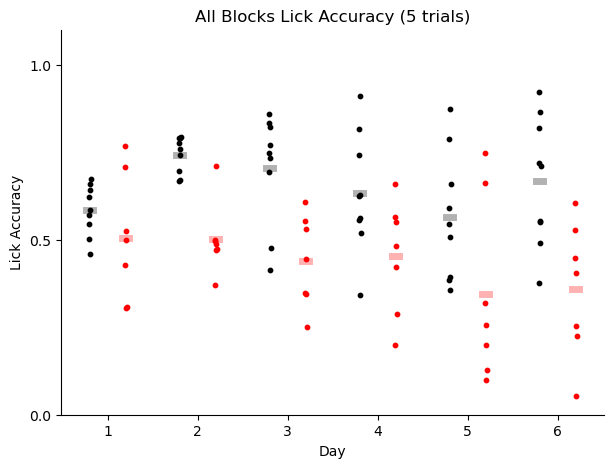

In [248]:
fig, ax = plt.subplots(1,1, figsize=[7,5])

lw = 5  
s = 10  # scatter size

days = sorted(all_data_df['day'].unique())

for group, color, offset in zip(['CTRL','KO'], ['black','red'], [-1, 1]):
    
    group_df = all_data_df[all_data_df['group'] == group]
    
    # Average per mouse per day across blocks
    mouse_day_means = group_df.groupby(['mouse','day'])['lick_acc_mean'].mean().reset_index()
    
    for day in days:
        day_data = mouse_day_means[mouse_day_means['day'] == day]
        vals = day_data['lick_acc_mean'].values
        
        # Scatter individual mice with horizontal jitter
        x_vals = 5*day + offset + np.linspace(-0.05, 0.05, num=vals.shape[0])
        ax.scatter(x_vals, vals, color=color, s=s)
        
        # Mean ± SEM across mice
        if len(vals) > 0:
            mean_val = np.mean(vals)
            ax.plot(5*day + offset + np.array([-0.2,0.2]), [mean_val, mean_val], color=color, linewidth=lw, alpha=0.3)


ax.set_xticks(np.arange(0,30,5))
ax.set_ylim(0,1.1)
ax.set_yticks([0,0.5,1])
ax.set_xticklabels([str(d+1) for d in days])
ax.set_xlabel('Day')
ax.set_ylabel('Lick Accuracy')
ax.set_title('All Blocks Lick Accuracy (5 trials)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()
# fig.savefig(os.path.join(fig_dir, 'NOV_lick_acc.pdf'))


In [249]:
# stats test each bin
mouse_day_means = all_data_df.groupby(['mouse','day','group'])['lick_acc_mean'].mean().reset_index()

days = sorted(mouse_day_means['day'].unique())
raw_p = []
day_labels = []

# two sided T test
for day in days:
    day_df = mouse_day_means[mouse_day_means['day'] == day]
    ctrl_vals = day_df[day_df['group'] == 'CTRL']['lick_acc_mean'].values
    ko_vals   = day_df[day_df['group'] == 'KO']['lick_acc_mean'].values

    _, p = ttest_ind(ctrl_vals, ko_vals, nan_policy='omit')
    raw_p.append(p)
    day_labels.append(day)

# FDR correction for mult comparisons
reject, p_fdr = fdrcorrection(raw_p, alpha=0.05)

# summary 
print("\n=== Lick Accuracy Stats: CTRL vs KO, per day ===")
for i, day in enumerate(day_labels):
    print(f"Day {day+1}: raw p = {raw_p[i]:.4f}, FDR p = {p_fdr[i]:.4f}, significant = {reject[i]}")



=== Lick Accuracy Stats: CTRL vs KO, per day ===
Day 1: raw p = 0.2525, FDR p = 0.2525, significant = False
Day 2: raw p = 0.0000, FDR p = 0.0002, significant = True
Day 3: raw p = 0.0030, FDR p = 0.0089, significant = True
Day 4: raw p = 0.0491, FDR p = 0.0736, significant = False
Day 5: raw p = 0.0625, FDR p = 0.0750, significant = False
Day 6: raw p = 0.0059, FDR p = 0.0118, significant = True


In [250]:
import statsmodels.formula.api as smf
model = smf.mixedlm("lick_acc_mean ~ group + day", data=mouse_day_means, groups=mouse_day_means["mouse"])
result = model.fit()

print(result.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: lick_acc_mean
No. Observations: 96      Method:             REML         
No. Groups:       16      Scale:              0.0166       
Min. group size:  6       Log-Likelihood:     40.7427      
Max. group size:  6       Converged:          Yes          
Mean group size:  6.0                                      
------------------------------------------------------------
             Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------
Intercept     0.695     0.043  15.994  0.000   0.609   0.780
group[T.KO]  -0.216     0.059  -3.670  0.000  -0.331  -0.101
day          -0.018     0.008  -2.320  0.020  -0.033  -0.003
Group Var     0.011     0.043                               



In [880]:
fig.savefig(os.path.join(figdir, 'lick_accuracy_allblocks_alldays.pdf'))

### Gross consummatory licks

In [74]:
# concat sess (4467331.2, 3) (4467332.2, 1) (mouse = '4467975.1', 0)
def get_concat_vr(mouse, day, ko):
    if ko=='CTRL':
        d = ctrl_sessions[mouse][day]
    else:
        d = ko_sessions[mouse][day]
    vr_data = []
    for i, sess_info in enumerate(d):
        date, scene, session, scan = sess_info['date'], sess_info['scene'], sess_info['session'], sess_info['scan']
        pkldir = os.path.join('C://Users/esay/data/Stx3/YMazeSessPkls/', mouse,  date, f'{scene}_{session}.pkl')
        sess = stx.session.YMazeSession.from_file(pkldir, verbose=False)
        
        data = sess.vr_data
        df = data.copy()

        vr_data.append(df)
    vr = pd.concat(vr_data, ignore_index = True)
    print(len(vr))
    frame_rate = sess.scan_info['frame_rate']
    
    return vr, frame_rate

def gross_consume(vr_data,framerate):
    window = (3*framerate)
    consume_licks = []

    vr_data['lick_corr'], _ = correct_lick_sensor_error(vr_data['lick'])
    rewards = vr_data['reward']

    reward_frames = vr_data.index[rewards==1]

    for r in reward_frames:
        end = min(r + window, len(vr_data))
        # print (r, end)
        lick_count = vr_data.loc[r:end, 'lick_corr'].sum()
        consume_licks.append(lick_count)
    return np.array(consume_licks)

def correct_lick_sensor_error(licks_, min_run = 10, thr=.2):

    licks = np.array(licks_, dtype=float)
    licks_clean = licks.copy()
    bad_segments = []

    high = licks > thr
    i = 0
    while i < len(high):
        if high[i]:
            # find run length
            start = i
            while i < len(high) and high[i]:
                i += 1
            end = i
            run_len = end - start
            if run_len >= min_run:
                licks_clean[start:end] = np.nan
                bad_segments.append((start, end))
        else:
            i += 1
    # print(bad_segments)

    return licks_clean, bad_segments

In [75]:
results = []

for group, mice in zip(['CTRL','KO'], [ctrl_mice, ko_mice]):
    for mouse in mice:
        for day in range(6):  
            sess = u.load_single_day(mouse, day)
            if isinstance(sess, stx.session.ConcatYMazeSession):
                # continue
                print('concat')
                vr_data, fr = get_concat_vr(mouse, day, ko = group)
                concat = True
            else:
                vr_data = sess.vr_data
                fr = sess.scan_info['frame_rate']

            gc = gross_consume(vr_data, fr)
                        
            results.append({
                'mouse': mouse,
                'group': group,
                'day': day,
                'gross_consume': gc
            })

df_consum = pd.DataFrame(results)


{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 7, 'novel_arm': -1, 'ravel_ind': 1}
{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 2}
{'date': '02_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 3}
{'date': '03_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': -1, 'ravel_ind': 4}
{'date': '04_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '01_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 2}
({'date': '02_12_2020', 'scene': 'YMaze_LNovel', 

c:\users\esay\repos\twoputils\TwoPUtils\sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:232: UserWarning: Could not find sbxmat file at /media/mplitt/Backup Plus3/2P_Data/4467333.1/05_12_2020/YMaze_LNovel/YMaze_LNovel_001_002.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:241: UserWarning: Could not find sbx file at /media/mplitt/Backup Plus3/2P_Data/4467333.1/05_12_2020/YMaze_LNovel/YMaze_LNovel_001_002.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '16_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 2}
{'date': '17_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 3}
{'date': '18_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 1, 'novel_arm': 1, 'ravel_ind': 4}
{'date': '19_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 1}
{'date': '16_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 2}
{'date': '17_10_2021', 'scene': 'YMaze_LNovel', 'ses

c:\users\esay\repos\twoputils\TwoPUtils\sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.1/28_09_2020/YMaze_LNovel/YMaze_LNovel_001_003.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.1/28_09_2020/YMaze_LNovel/YMaze_LNovel_001_003.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


28_09_2020 YMaze_LNovel


...

{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 4}


c:\users\esay\repos\twoputils\TwoPUtils\sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.3/02_10_2020/YMaze_LNovel/YMaze_LNovel_001_003.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.3/02_10_2020/YMaze_LNovel/YMaze_LNovel_001_003.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 6, 'novel_arm': -1, 'ravel_ind': 5}


c:\users\esay\repos\twoputils\TwoPUtils\sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.3/03_10_2020/YMaze_LNovel/YMaze_LNovel_001_006.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.3/03_10_2020/YMaze_LNovel/YMaze_LNovel_001_006.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 2}
{'date': '01_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 3}
{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 4}
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 1}
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': -1, 'ravel_ind': 2}
{'date': '01_10_2020', 'scene': 'YMaze_LNovel', 'ses

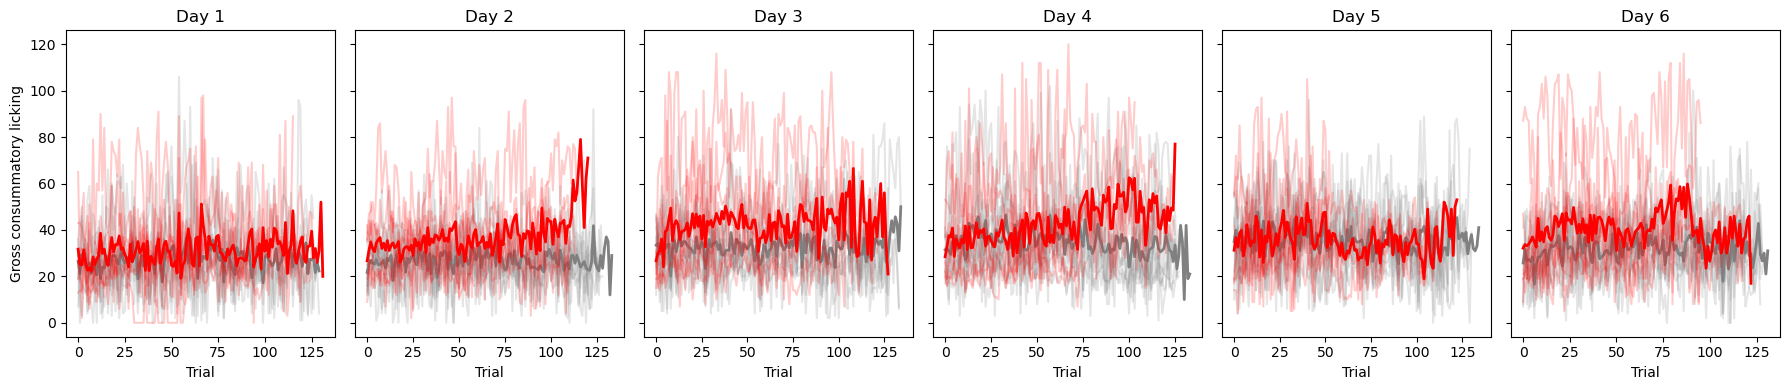

In [251]:
def plot_consum_compact(df_consum):
    days = sorted(df_consum['day'].unique())
    groups = df_consum['group'].unique()
    n_days = len(days)

    fig, axes = plt.subplots(1, n_days, figsize=(3*n_days, 4), sharey=True)

    if n_days == 1:
        axes = [axes]  

    for ax, day in zip(axes, days):
        ax.set_title(f"Day {day+1}")

        for group in groups:
            group_df = df_consum[(df_consum['day']==day) & (df_consum['group']==group)]
            all_trials = []

            for _, row in group_df.iterrows():
                gc = row['gross_consume']
                ax.plot(gc, 
                        color='grey' if group=='CTRL' else 'red', 
                        alpha=0.2)
                all_trials.append(gc)

            # mean
            max_len = max(len(x) for x in all_trials)
            arr = np.full((len(all_trials), max_len), np.nan)
            for i, x in enumerate(all_trials):
                arr[i, :len(x)] = x
            mean_gc = np.nanmean(arr, axis=0)

            # plot mean
            ax.plot(mean_gc, 
                    color='grey' if group=='CTRL' else 'red', 
                    linewidth=2, 
                    label=group)

        ax.set_xlabel("Trial")

    axes[0].set_ylabel("Gross consummatory licking")
    # axes[0].legend()
    fig.tight_layout()
    plt.show()
    fig.savefig(os.path.join(fig_dir, 'gross_lick_2sec.pdf'))
plot_consum_compact(df_consum)

In [82]:
def add_mean_gross_consume(df):
    df = df.copy()
    df['gross_consume_mean'] = df['gross_consume'].apply(
        lambda arr: np.nanmean(arr) if isinstance(arr, (list, np.ndarray)) else np.nan
    )
    return df
df = add_mean_gross_consume(df_consum)

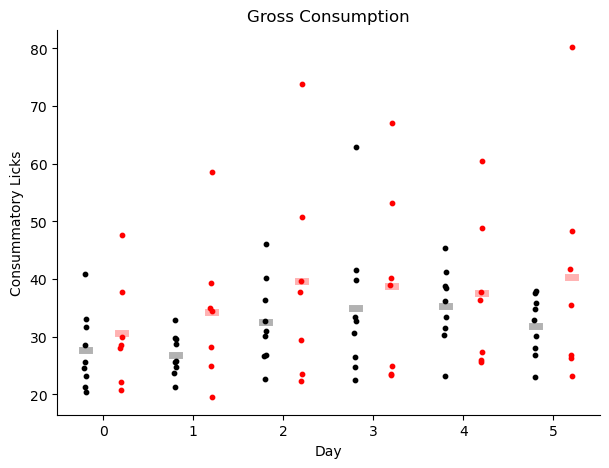

In [84]:
# df = df_consum

fig, ax = plt.subplots(1, 1, figsize=[7,5]) 

lw = 5   #
s = 10   
key = 'gross_consume_mean'  

for day in range(6):
    
    mask = (df['group']=='CTRL') & (df['day']==day)
    vals = df[key].loc[mask]._values
    ax.scatter(5*day - 1 + np.linspace(-0.05, 0.05, num=vals.shape[0]), vals, color='black', s=s)
    ax.plot(5*day - 1 + np.array([-0.2,0.2]), vals.mean()*np.ones([2,]), color='black', linewidth=lw, alpha=0.3)
    
    mask = (df['group']=='KO') & (df['day']==day)
    vals = df[key].loc[mask]._values
    ax.scatter(5*day + 1 + np.linspace(-0.05, 0.05, num=vals.shape[0]), vals, color='red', s=s)
    ax.plot(5*day + 1 + np.array([-0.2,0.2]), vals.mean()*np.ones([2,]), color='red', linewidth=lw, alpha=0.3)


ax.set_xticks(np.arange(0,6*5,5))
ax.set_xticklabels([x for x in range(0,6)])
ax.set_xlabel('Day')
ax.set_ylabel('Consummatory Licks')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Gross Consumption')

plt.show()
fig.savefig(os.path.join(fig_dir, 'gross_consumm_summ.pdf'))

### Slowing analysis for blocks 2-5

In [57]:
results = {}

speed_max_bin = 30

transitions = [1, 2, 3, 4, 5]  # block numbers

for cond, mice in zip(('ctrl', 'cre'), (ctrl_mice, ko_mice)):
    results[cond] = {}
    for day in range(6):
        results[cond][day] = {}
        for mouse in mice:

            d = {} 
            sess = u.load_vr_day(mouse, day)

            for t in transitions:
                try:
                    first_block_ind = np.argwhere(sess.trial_info['block_number'] == t)[0][0]
                except IndexError:
                    # skip if this block doesn't exist in session
                    continue

                baseline_trials = slice(first_block_ind-10, first_block_ind)
                this_block = sess.trial_info['block_number'] == t

                d[f'block{t}_lr'] = sess.trial_info['LR'][this_block]

                baseline_avg_speed = np.nanmean(
                    sess.trial_matrices['speed'][baseline_trials, :speed_max_bin], 
                    axis=0, 
                    keepdims=True
                ).mean()

                # normalize to baseline
                d[f'block{t}_baseline_speed'] = np.nanmean(
                    sess.trial_matrices['speed'][baseline_trials, :speed_max_bin] / baseline_avg_speed, 
                    axis=-1
                )
                d[f'block{t}_fam_speed'] = np.nanmean(
                    sess.trial_matrices['speed'][this_block, :speed_max_bin] / baseline_avg_speed, 
                    axis=-1
                )

            results[cond][day][mouse] = d


{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 18, 'novel_arm': 1, 'ravel_ind': 1}


C:\Users\esay\AppData\Local\Temp\ipykernel_295244\1236476389.py:28: RuntimeWarning: Mean of empty slice
  baseline_avg_speed = np.nanmean(
C:\Users\esay\AppData\Local\Temp\ipykernel_295244\1236476389.py:39: RuntimeWarning: Mean of empty slice
  d[f'block{t}_fam_speed'] = np.nanmean(


{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 7, 'novel_arm': -1, 'ravel_ind': 1}
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 1}
({'date': '30_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 2}, {'date': '30_11_2020', 'scene': 'YMaze_LNovel', '

C:\Users\esay\AppData\Local\Temp\ipykernel_295244\1236476389.py:28: RuntimeWarning: Mean of empty slice
  baseline_avg_speed = np.nanmean(
C:\Users\esay\AppData\Local\Temp\ipykernel_295244\1236476389.py:39: RuntimeWarning: Mean of empty slice
  d[f'block{t}_fam_speed'] = np.nanmean(


{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 1}
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '29_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 1}
{'date': '19_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 1}
{'date': '19_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 3}
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 2}
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 7, 'novel_arm': -1, 'ravel_ind': 2}
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 2}
{'date': '30_09_2020', 'scene': 'YMaze_LNovel', 's

C:\Users\esay\AppData\Local\Temp\ipykernel_295244\1236476389.py:28: RuntimeWarning: Mean of empty slice
  baseline_avg_speed = np.nanmean(
C:\Users\esay\AppData\Local\Temp\ipykernel_295244\1236476389.py:39: RuntimeWarning: Mean of empty slice
  d[f'block{t}_fam_speed'] = np.nanmean(


{'date': '01_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 3}
{'date': '01_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 7, 'novel_arm': -1, 'ravel_ind': 3}
{'date': '01_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 3}
{'date': '01_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 7, 'novel_arm': -1, 'ravel_ind': 3}
{'date': '21_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 3}
{'date': '21_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 3}
{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 9, 'novel_arm': 1, 'ravel_ind': 4}
{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 4}
{'date': '02_10_2020', 'scene': 'YMaze_LNovel', 's

C:\Users\esay\AppData\Local\Temp\ipykernel_295244\1236476389.py:28: RuntimeWarning: Mean of empty slice
  baseline_avg_speed = np.nanmean(
C:\Users\esay\AppData\Local\Temp\ipykernel_295244\1236476389.py:39: RuntimeWarning: Mean of empty slice
  d[f'block{t}_fam_speed'] = np.nanmean(
C:\Users\esay\AppData\Local\Temp\ipykernel_295244\1236476389.py:28: RuntimeWarning: Mean of empty slice
  baseline_avg_speed = np.nanmean(
C:\Users\esay\AppData\Local\Temp\ipykernel_295244\1236476389.py:39: RuntimeWarning: Mean of empty slice
  d[f'block{t}_fam_speed'] = np.nanmean(


{'date': '22_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 4}
{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 4}
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 6}
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 6, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 5}


C:\Users\esay\AppData\Local\Temp\ipykernel_295244\1236476389.py:28: RuntimeWarning: Mean of empty slice
  baseline_avg_speed = np.nanmean(
C:\Users\esay\AppData\Local\Temp\ipykernel_295244\1236476389.py:39: RuntimeWarning: Mean of empty slice
  d[f'block{t}_fam_speed'] = np.nanmean(


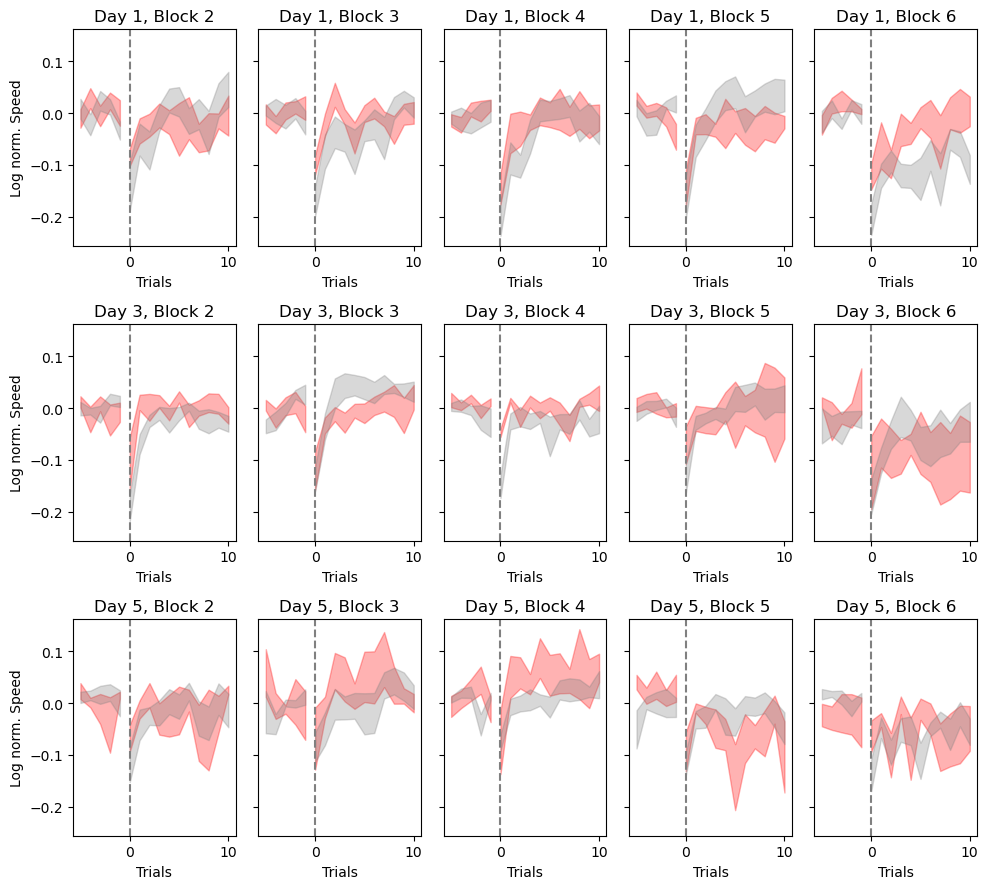

In [64]:
# import numpy as np
# import matplotlib.pyplot as plt
# import scipy as sp

days = [0,2,4]  
blocks = [1,2,3,4,5] # transitions
ko_mice = list(results['cre'][0].keys())
ctrl_mice = list(results['ctrl'][0].keys())

fig, axes = plt.subplots(len(days), len(blocks), figsize=(10, 3*len(days)), sharey=True)

for i, day in enumerate(days):
    for j, t in enumerate(blocks):
        ax = axes[i, j] if len(days) > 1 else axes[j]

        # cre
        ko_fam = np.full((len(ko_mice), 11), np.nan)
        ko_base = np.full((len(ko_mice), 5), np.nan)

        for m, mouse in enumerate(ko_mice):
            d = results['cre'][day][mouse]
            if f'block{t}_fam_speed' not in d or f'block{t}_baseline_speed' not in d:
                continue

            base_vals = d[f'block{t}_baseline_speed'][-5:]
            fam_vals = d[f'block{t}_fam_speed'][:11]

            if base_vals.size == 5:
                ko_base[m, :] = np.log10(base_vals)

            if fam_vals.size > 0:
                _vals = np.log10(fam_vals)
                ko_fam[m, :_vals.shape[0]] = _vals

        # plot CRE if valid
        if not np.all(np.isnan(ko_base)):
            x_base = np.arange(-5, 0)
            mu_b = np.nanmean(ko_base, axis=0)
            sem_b = sp.stats.sem(ko_base, axis=0, nan_policy='omit')
            ax.fill_between(x_base, mu_b-sem_b, mu_b+sem_b, color='red', alpha=.3)

        if not np.all(np.isnan(ko_fam)):
            x_fam = np.arange(11)
            mu_s = np.nanmean(ko_fam, axis=0)
            sem_s = sp.stats.sem(ko_fam, axis=0, nan_policy='omit')
            ax.fill_between(x_fam, mu_s-sem_s, mu_s+sem_s, color='red', alpha=.3)

        # ctrl
        ctrl_fam = np.full((len(ctrl_mice), 11), np.nan)
        ctrl_base = np.full((len(ctrl_mice), 5), np.nan)

        for m, mouse in enumerate(ctrl_mice):
            d = results['ctrl'][day][mouse]
            if f'block{t}_fam_speed' not in d or f'block{t}_baseline_speed' not in d:
                continue

            base_vals = d[f'block{t}_baseline_speed'][-5:]
            fam_vals = d[f'block{t}_fam_speed'][:11]

            if base_vals.size == 5:
                ctrl_base[m, :] = np.log10(base_vals)

            if fam_vals.size > 0:
                _vals = np.log10(fam_vals)
                ctrl_fam[m, :_vals.shape[0]] = _vals

        if not np.all(np.isnan(ctrl_base)):
            x_base = np.arange(-5, 0)
            mu_b = np.nanmean(ctrl_base, axis=0)
            sem_b = sp.stats.sem(ctrl_base, axis=0, nan_policy='omit')
            ax.fill_between(x_base, mu_b-sem_b, mu_b+sem_b, color='grey', alpha=.3)

        if not np.all(np.isnan(ctrl_fam)):
            x_fam = np.arange(11)
            mu_s = np.nanmean(ctrl_fam, axis=0)
            sem_s = sp.stats.sem(ctrl_fam, axis=0, nan_policy='omit')
            ax.fill_between(x_fam, mu_s-sem_s, mu_s+sem_s, color='grey', alpha=.3)

        ax.axvline(0, color='grey', linestyle='--')  # dotted line separation
        ax.set_title(f"Day {day+1}, Block {t+1}")
        ax.set_xlabel("Trials")
        if j == 0:
            ax.set_ylabel("Log norm. Speed")

plt.tight_layout()
plt.show()

fig.savefig(os.path.join(fig_dir, 'all_blocks_day0_1_4.pdf'))

### Overall running speed differences in block 6 transition
ie. do not normalize

In [263]:
results = {}

speed_max_bin = 30

for cond, mice in zip(('ctrl', 'cre'),(ctrl_mice, ko_mice)):
    results[cond] = {}
    for day in range(6):
        results[cond][day] = {}
        for mouse in mice:
            
            d = {} 
            sess = u.load_single_day(mouse, day)

            
            last_block_ind = np.argwhere(sess.trial_info['block_number']==5)[0][0]

            baseline_trials = slice(last_block_ind-10, last_block_ind)

            last_block = sess.trial_info['block_number']==5
            fam_last_block = (sess.trial_info['block_number']==5)*(sess.trial_info['LR']==-1*sess.novel_arm)
            nov_last_block = (sess.trial_info['block_number']==5)*(sess.trial_info['LR']==sess.novel_arm)
            
            d['last_block_lr'] = sess.trial_info['LR'][last_block]
            
            baseline_avg_speed = np.nanmean(sess.trial_matrices['speed'][baseline_trials,:speed_max_bin], axis=0, keepdims=True).mean()
            
            d['baseline_speed'] = np.nanmean(sess.trial_matrices['speed'][baseline_trials,:speed_max_bin], axis=-1)
            d['last_block_speed'] = np.nanmean(sess.trial_matrices['speed'][last_block,:speed_max_bin], axis=-1)
            d['fam_speed'] = np.nanmean(sess.trial_matrices['speed'][fam_last_block,:speed_max_bin], axis=-1)
            d['nov_speed'] = np.nanmean(sess.trial_matrices['speed'][nov_last_block,:speed_max_bin], axis=-1)
            
            results[cond][day][mouse] = d


{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 18, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', '

c:\users\esay\repos\twoputils\TwoPUtils\sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:232: UserWarning: Could not find sbxmat file at /media/mplitt/Backup Plus3/2P_Data/4467333.1/05_12_2020/YMaze_LNovel/YMaze_LNovel_001_002.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:241: UserWarning: Could not find sbx file at /media/mplitt/Backup Plus3/2P_Data/4467333.1/05_12_2020/YMaze_LNovel/YMaze_LNovel_001_002.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '19_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '19_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '20_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '21_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}
({'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}, {'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 6, 'scan': 14, 'novel_arm': -1, 'ravel_ind': 1})


c:\users\esay\repos\twoputils\TwoPUtils\sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.1/28_09_2020/YMaze_LNovel/YMaze_LNovel_001_003.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.1/28_09_2020/YMaze_LNovel/YMaze_LNovel_001_003.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


28_09_2020 YMaze_LNovel


...

{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': 1, 'ravel_ind': 5}


c:\users\esay\repos\twoputils\TwoPUtils\sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.2/03_10_2020/YMaze_LNovel/YMaze_LNovel_001_008.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.2/03_10_2020/YMaze_LNovel/YMaze_LNovel_001_008.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 6, 'novel_arm': -1, 'ravel_ind': 5}


c:\users\esay\repos\twoputils\TwoPUtils\sess.py:100: UserWarning: skipping checking keys, remaining initialization not guaranteed to work
  warnings.warn("skipping checking keys, remaining initialization not guaranteed to work")
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:232: UserWarning: Could not find sbxmat file at /mnt/BigDisk/2P_scratch/4467975.3/03_10_2020/YMaze_LNovel/YMaze_LNovel_001_006.mat
  warnings.warn("Could not find sbxmat file at %s" % self.scanheader_file)
c:\users\esay\repos\twoputils\TwoPUtils\sess.py:241: UserWarning: Could not find sbx file at /mnt/BigDisk/2P_scratch/4467975.3/03_10_2020/YMaze_LNovel/YMaze_LNovel_001_006.sbx
  warnings.warn("Could not find sbx file at %s" % self.scan_file)


{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 5}


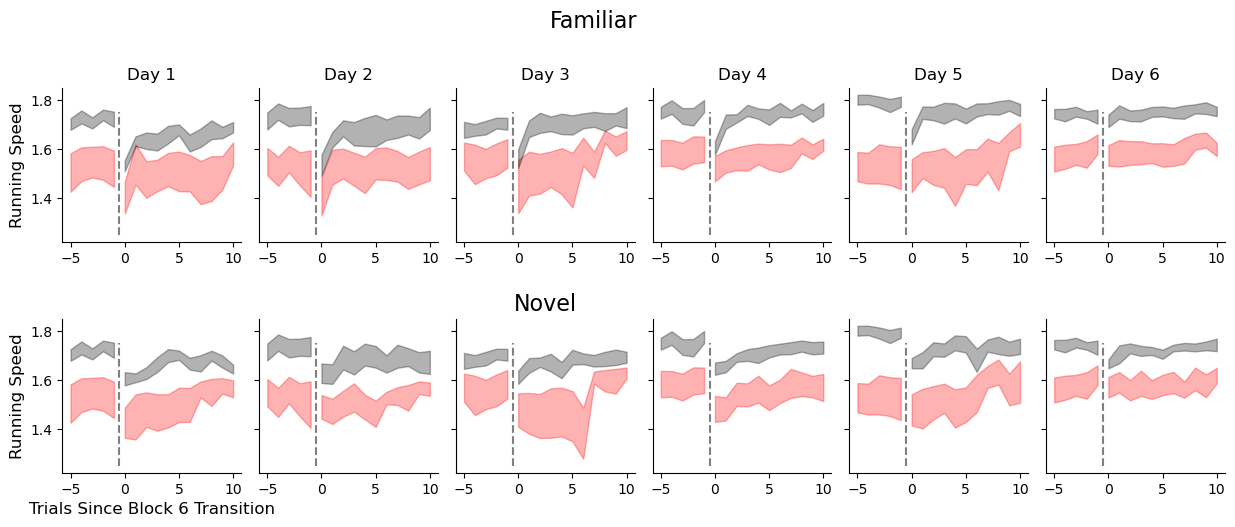

In [297]:
fig,ax = plt.subplots(2,6, figsize = [15, 5],sharey=True)
# ax[0,0].set_ylim([.5,1.2])

n_trials_anova = 2
df = {
      'mouse': [],
      'cond': [],
      'day': [],
      'fam_speed':[],
      'nov_speed': [],
     }

for day in range(6):
    
    
#      familiar
    ko_base = np.zeros((len(ko_mice), 5))*np.nan
    ko_fam_speed = np.zeros((len(ko_mice), 11))*np.nan
    ko_nov_speed = np.zeros((len(ko_mice), 11))*np.nan
    for m, mouse in enumerate(ko_mice):
        d = results['cre'][day][mouse]
        ko_base[m,:] = np.log10(d['baseline_speed'][-5:])
        
        _speed = np.log10(d['fam_speed'][:11])
        ko_fam_speed[m,:_speed.shape[0]] = _speed[:11]
        
        _speed = np.log10(d['nov_speed'][:11])
        ko_nov_speed[m,:_speed.shape[0]] = _speed[:11]
        
        df['mouse'].append(mouse)
        df['cond'].append('cre')
        df['day'].append(day)
        df['fam_speed'].append(np.log10(np.nanmean(d['fam_speed'][:n_trials_anova])))
        df['nov_speed'].append(np.log10(np.nanmean(d['nov_speed'][:n_trials_anova])))
        # df['fam_speed'].append(np.log10(np.nanmean(d['fam_speed'][:n_trials_anova])))
        # df['nov_speed'].append(np.log10(np.nanmean(d['nov_speed'][:n_trials_anova])))
        
        


    x_base = np.arange(-5,0)
    x_speed = np.arange(0, 11)
    mu_b, sem_b = np.nanmean(ko_base, axis=0), sp.stats.sem(ko_base, axis=0, nan_policy='omit')
    ax[0, day].fill_between(x_base, mu_b-sem_b, mu_b+sem_b, color='red', alpha=.3)
    ax[1, day].fill_between(x_base, mu_b-sem_b, mu_b+sem_b, color='red', alpha=.3)

    mu_s, sem_s = np.nanmean(ko_fam_speed, axis=0), sp.stats.sem(ko_fam_speed, axis=0, nan_policy='omit')
    ax[0, day].fill_between(x_speed, mu_s-sem_s, mu_s+sem_s, color='red', alpha=.3)
    
    mu_s, sem_s = np.nanmean(ko_nov_speed, axis=0), sp.stats.sem(ko_nov_speed, axis=0, nan_policy='omit')
    ax[1, day].fill_between(x_speed, mu_s-sem_s, mu_s+sem_s, color='red', alpha=.3)
    
    
    
 


    ctrl_base = np.zeros((len(ctrl_mice), 5))*np.nan
    ctrl_fam_speed = np.zeros((len(ctrl_mice), 11))*np.nan
    ctrl_nov_speed = np.zeros((len(ctrl_mice), 11))*np.nan
    for m, mouse in enumerate(ctrl_mice):
        d = results['ctrl'][day][mouse]
        
        ctrl_base[m,:] = np.log10(d['baseline_speed'][-5:])
        
        _speed = np.log10(d['fam_speed'][:11])
        ctrl_fam_speed[m,:_speed.shape[0]] = _speed[:11]
        
        _speed = np.log10(d['nov_speed'][:11])
        ctrl_nov_speed[m,:_speed.shape[0]] = _speed[:11]
        
        df['mouse'].append(mouse)
        df['cond'].append('ctrl')
        df['day'].append(day)
        df['fam_speed'].append(np.log10(np.nanmean(d['fam_speed'][:n_trials_anova])))
        df['nov_speed'].append(np.log10(np.nanmean(d['nov_speed'][:n_trials_anova])))        

    mu_b, sem_b = ctrl_base.mean(axis=0), sp.stats.sem(ctrl_base, axis=0)
    ax[0, day].fill_between(x_base, mu_b-sem_b, mu_b+sem_b, color='black', alpha=.3)
    ax[1, day].fill_between(x_base, mu_b-sem_b, mu_b+sem_b, color='black', alpha=.3)

    mu_s, sem_s = ctrl_fam_speed.mean(axis=0), sp.stats.sem(ctrl_fam_speed, axis=0)
    ax[0, day].fill_between(x_speed, mu_s-sem_s, mu_s+sem_s, color='black', alpha=.3)
    
    mu_s, sem_s = ctrl_nov_speed.mean(axis=0), sp.stats.sem(ctrl_nov_speed, axis=0)
    ax[1, day].fill_between(x_speed, mu_s-sem_s, mu_s+sem_s, color='black', alpha=.3)
    
    

    
    ax[0,day].plot([-.5, -.5],[1.25,1.75],'k--', alpha = .5)
    ax[1,day].plot([-.5, -.5],[1.25,1.75],'k--', alpha = .5)
    
    # ax[0,day].set_xticks([-5, 0, 5, 10])
    # ax[1,day].set_xticks([-5, 0, 5, 10])
    
    
    ax[0,day].spines['top'].set_visible(False)
    ax[1,day].spines['top'].set_visible(False)
    ax[0,day].set_title(f"Day {day+1}")
    # ax[1,day].set_title(f"Day {day+1}")
    
    ax[0,day].spines['right'].set_visible(False)
    ax[1,day].spines['right'].set_visible(False)
    
ax[0,0].set_ylabel('Running Speed', fontsize=12)
# ax[0,0].set_xlabel('Trials Since Block 6 Transition')

ax[1,0].set_ylabel('Running Speed',fontsize=12)
ax[1,0].set_xlabel('Trials Since Block 6 Transition', fontsize=12)
fig.text(.45,1,"Familiar",fontsize=16)
ax[1,2].set_title("Novel",fontsize=16)

plt.subplots_adjust(hspace=0.5,wspace=0.1)
df = pd.DataFrame(df)

figdir = 'C:/Users/esay/data/Stx3/YMazeResults/behavior'
fig.savefig(os.path.join(figdir,"relative_speed_all_days.pdf"),format='pdf')

### Speed CV over whole track

{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 6}
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 6, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '23_10_2021', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 5}
{'date': '04_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 5}
{'date': '04_12_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 6}
{'date': '04_12_2020', 'scene': 'YMaze_LNovel', 's

C:\Users\esay\AppData\Local\Temp\ipykernel_295244\3920634167.py:30: DeprecationWarning: Please import `sem` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  sem = sp.stats.sem(arr, axis=0, nan_policy='omit')
C:\Users\esay\AppData\Local\Temp\ipykernel_295244\3920634167.py:57: DeprecationWarning: Please import `sem` from the `scipy.stats` namespace; the `scipy.stats.stats` namespace is deprecated and will be removed in SciPy 2.0.0.
  sem = sp.stats.sem(arr, axis=0, nan_policy='omit')


Text(0.5, 0.98, 'Day 6')

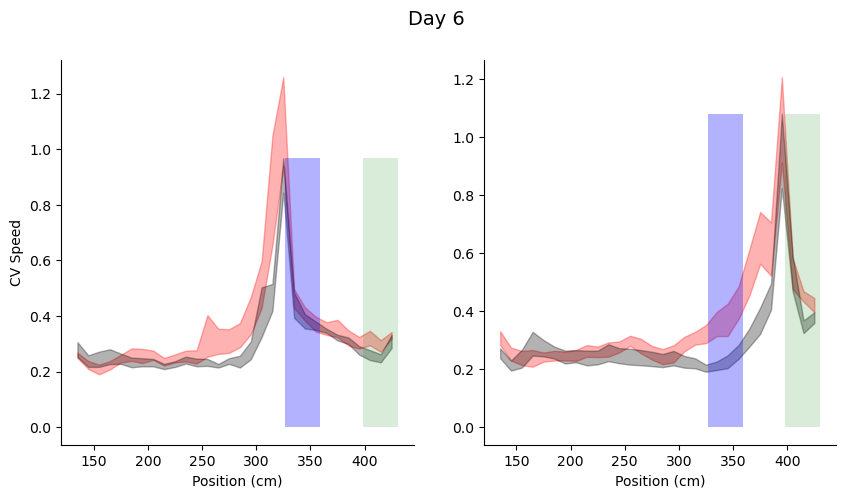

In [184]:
fig, ax = plt.subplots(1, 2, figsize=[10, 5])
days = range(6)
day = 5
ko_mu = {-1: [], 1: []}
# for day in days:
for mouse in ko_mice:
    sess = u.load_vr_day(mouse, day=day)
    n_bins = sess.trial_matrices['speed'].shape[1]
    for ax_ind, lr in enumerate([-1, 1]):
        trial_mask = sess.trial_info['LR'] == lr
        run_mean = np.nanmean(sess.trial_matrices['speed'][trial_mask, :].ravel())
        # print(run_mean)

        trial_speeds = sess.trial_matrices['speed'][trial_mask, :]  
        if trial_speeds.size == 0 or trial_speeds.shape[0] == 0:
            cv = np.full(n_bins, np.nan)
        else:
            mean_per_bin = np.nanmean(trial_speeds, axis=0)
            std_per_bin = np.nanstd(trial_speeds, axis=0)
            # CV calc
            with np.errstate(divide='ignore', invalid='ignore'):
                cv = std_per_bin / mean_per_bin
            cv = np.where(mean_per_bin == 0, np.nan, cv)

        ko_mu[lr].append(cv)

for ax_ind, lr in enumerate([-1, 1]):
    arr = np.array(ko_mu[lr])
    mu = np.nanmean(arr, axis=0)
    sem = sp.stats.sem(arr, axis=0, nan_policy='omit')
    ax[ax_ind].fill_between(sess.trial_matrices['bin_centers']*10, mu - sem, mu + sem, color='red', alpha=.3)

ctrl_mu = {-1: [], 1: []}
for mouse in ctrl_mice:
    sess = u.load_vr_day(mouse, day=day)
    n_bins = sess.trial_matrices['speed'].shape[1]
    for ax_ind, lr in enumerate([-1, 1]):
        trial_mask = sess.trial_info['LR'] == lr
        run_mean = np.nanmean(sess.trial_matrices['speed'][trial_mask, :].ravel())
        # print(run_mean)

        trial_speeds = sess.trial_matrices['speed'][trial_mask, :]  
        if trial_speeds.size == 0 or trial_speeds.shape[0] == 0:
            cv = np.full(n_bins, np.nan)
        else:
            mean_per_bin = np.nanmean(trial_speeds, axis=0)
            std_per_bin = np.nanstd(trial_speeds, axis=0)
            with np.errstate(divide='ignore', invalid='ignore'):
                cv = std_per_bin / mean_per_bin
            cv = np.where(mean_per_bin == 0, np.nan, cv)

        ctrl_mu[lr].append(cv)

for ax_ind, lr in enumerate([-1, 1]):
    arr = np.array(ctrl_mu[lr])
    mu = np.nanmean(arr, axis=0)
    sem = sp.stats.sem(arr, axis=0, nan_policy='omit')
    # print(sess.trial_matrices['bin_centers'])
    ax[ax_ind].fill_between(sess.trial_matrices['bin_centers']*10, mu - sem, mu + sem, color='black', alpha=.3)
    ax[ax_ind].fill_betweenx(
        [0, np.nanmax(mu + sem)],
        sess.rzone_late['tfront']*10,
        sess.rzone_late['tback']*10,
        color="green", alpha=.15, linewidth=0#hatch="/", edgecolor="green", 
    )
    ax[ax_ind].fill_betweenx(
        [0, np.nanmax(mu + sem)],
        sess.rzone_early['tfront']*10,
        sess.rzone_early['tback']*10,
        color="blue", alpha=.3, linewidth=0
    )
    
ax[0].set_xlabel('Position (cm)')
ax[1].set_xlabel('Position (cm)')
ax[0].set_ylabel('CV Speed')
ax[0].spines['top'].set_visible(False)
ax[1].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[1].spines['right'].set_visible(False)
fig.suptitle(f'Day {day+1}',fontsize=14)

# fig.savefig(os.path.join(figdir, 'LR_cv_speed_day6.pdf'))


In [181]:
def compute_cv(sess):
    """
    Coefficient of variation (CV = std / mean) of speed across trials

    """
    n_bins = sess.trial_matrices['speed'].shape[1]
    cv_dict = {}

    for lr in [-1, 1]:  # LEeft -1 Right 1
        trial_mask = sess.trial_info['LR'] == lr
        trial_speeds = sess.trial_matrices['speed'][trial_mask, :]

        if trial_speeds.size == 0 or trial_speeds.shape[0] == 0:
            cv = np.full(n_bins, np.nan)

        else:
            mean_per_bin = np.nanmean(trial_speeds, axis=0)
            std_per_bin = np.nanstd(trial_speeds, axis=0)

            # CV calculation 
            with np.errstate(divide='ignore', invalid='ignore'):
                cv = std_per_bin / mean_per_bin
            cv = np.where(mean_per_bin == 0, np.nan, cv)

        cv_dict[lr] = cv

    return cv_dict


In [182]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import fdrcorrection

def auc(x, y):
    return np.trapz(y, x)

days = range(6)   
arms = [-1, 1]    # Left -1 Right 1

p_vals = {arm: [] for arm in arms}


auc_ko_days = {arm: [] for arm in arms}
auc_ctrl_days = {arm: [] for arm in arms}

for day in days:
    for arm in arms:
        auc_ko = []
        auc_ctrl = []

        for mouse in ko_mice:
            sess = u.load_vr_day(mouse, day=day)
            cv = compute_cv(sess)         # cv is a dict: {-1: cv array, 1: cv array}
            pos = sess.trial_matrices['bin_centers'] * 10   
            auc_ko.append(np.trapz(cv[arm], pos))

        for mouse in ctrl_mice:
            sess = u.load_vr_day(mouse, day=day)
            cv = compute_cv(sess)
            pos = sess.trial_matrices['bin_centers'] * 10
            auc_ctrl.append(np.trapz(cv[arm], pos))

        auc_ko_days[arm].append(auc_ko)
        auc_ctrl_days[arm].append(auc_ctrl)

        _, p = ttest_ind(auc_ko, auc_ctrl, nan_policy='omit')
        p_vals[arm].append(p)

# correct for mult comparisons (days)
for arm in arms:
    reject, p_vals_fdr = fdrcorrection(p_vals[arm], alpha=0.05)

    print(f"\n--- Arm = {arm} (-1=Left, 1=Right) ---")
    for i, day in enumerate(days):
        print(f"Day {day+1}: raw p = {p_vals[arm][i]:.4f}, "
              f"FDR-corrected p = {p_vals_fdr[i]:.4f}, "
              f"significant = {reject[i]}")


({'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}, {'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 6, 'scan': 14, 'novel_arm': -1, 'ravel_ind': 1})
{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 3, 'scan': 8, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 5, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '28_09_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '18_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '18_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel

### Trials per block (seaborn heatmap)

{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 8, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 2, 'scan': 18, 'novel_arm': 1, 'ravel_ind': 1}
{'date': '29_11_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 4, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 2, 'novel_arm': -1, 'ravel_ind': 0}
{'date': '14_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '15_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': 1, 'ravel_ind': 0}
{'date': '30_11_2020', 'scene': 'YMaze_LNovel', 's

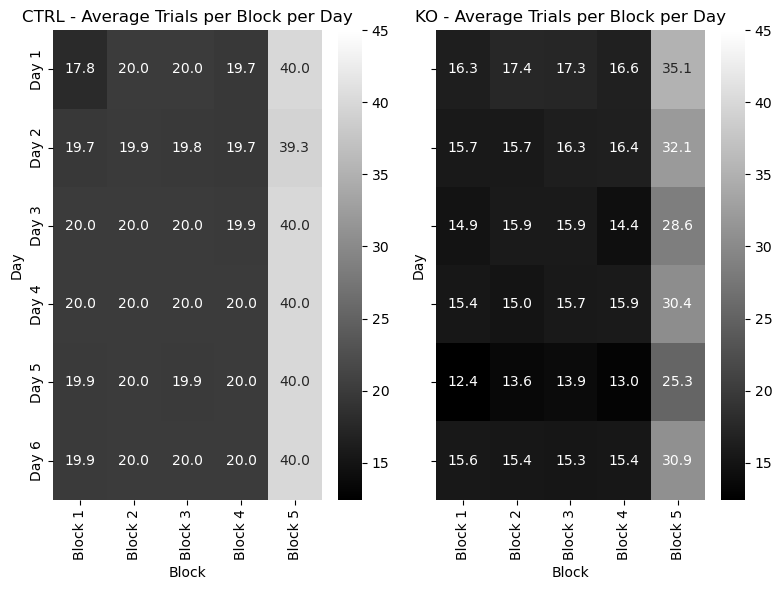

In [252]:
import seaborn as sns

days = range(0, 6)          
max_blocks = 5              
groups = {'CTRL': ctrl_mice, 'KO': ko_mice}

def count_trials_group(group_mice):
    mat = pd.DataFrame(
        0, 
        index=[f"Day {d+1}" for d in days], 
        columns=[f"Block {b+1}" for b in range(max_blocks)]
    )
    for day in days:
        for mouse in group_mice:
            sess = u.load_vr_day(mouse, day=day)
            for block in range(max_blocks):
                mat.loc[f"Day {day+1}", f"Block {block+1}"] += np.sum(sess.trial_info['block_number'] == block+1)
    return mat/len(group_mice)

trial_matrices = {grp: count_trials_group(mice) for grp, mice in groups.items()}

all_vals = np.concatenate([trial_matrices['CTRL'].values.flatten(),
                           trial_matrices['KO'].values.flatten()])
vmin = all_vals.min()
vmax = all_vals.max() +5

fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharey=True)

for ax, grp in zip(axes, groups.keys()):
    sns.heatmap(
        trial_matrices[grp], 
        annot=True, 
        fmt='.1f', 
        cmap='grey', 
        ax=ax,
        vmin = vmin, 
        vmax = vmax
    )
    ax.set_title(f'{grp} - Average Trials per Block per Day')
    ax.set_xlabel('Block')
    ax.set_ylabel('Day')

plt.tight_layout()
plt.show()
# fig.savefig(os.path.join(fig_dir, 'trials_per_block.pdf'))

In [227]:
plt.show()